## Блок 1: Инициализация и подготовка среды

Описание: подготовка рабочего пространства — импорт библиотек, настройка путей, служебные функции многоразового использования.

In [1]:
# Подблок 1.1 — Импорт библиотек
import re                       # разбор имён файлов (год/неделя)
from pathlib import Path        # удобная работа с путями
import pandas as pd             # работа с табличными данными

In [2]:
# Подблок 1.2 — Константы проекта (пути, ожидаемые параметры)
RAW_DIR = Path(r"C:\Users\irma4\Desktop\final_project_hse_eremina\data\raw")
PROCESSED_DIR = Path(r"C:\Users\irma4\Desktop\final_project_hse_eremina\data\processed")

SKIPROWS = 1                    # число строк шапки отчёта 1С перед таблицей
EXPECTED_WEEKS_PER_SEASON = 18  # ожидаемое число недель в каждом сезоне
SEASON_START_WEEK = 40          # неделя, с которой начинается новогодний сезон

# создание папки для промежуточных результатов
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Подблок 1.3 — Служебная функция разбора имени файла
# Имя файла кодирует *календарный* год и неделю (например, `2025_01W`). Сезон длится с недели 40 одного года по неделю 05 следующего, поэтому файл `2025_01W` относится к сезону 2024, а файл `2025_40W` — уже к сезону 2025.
FILENAME_PATTERN = re.compile(r"(\d{4})_(\d{2})W")

def parse_season(filename):
    """Извлечение (календарный год, номер недели, сезон) из имени файла.
    Пример: 2025_01W -> сезон 2024; 2025_40W -> сезон 2025.
    """
    match = FILENAME_PATTERN.search(filename)
    if not match:
        raise ValueError(
            f"Не удалось распознать год/неделю в имени файла: {filename}"
        )
    year, week = int(match.group(1)), int(match.group(2))
    season = year if week >= SEASON_START_WEEK else year - 1
    return year, week, season

## Блок 2: Загрузка и консолидация данных

Описание: поиск исходных файлов, чтение каждого с разметкой по сезону, объединение в единый датасет.

Вместо ручного чтения 36 файлов используется цикл — это исключает ошибки, экономит время и делает код масштабируемым. Поле `source_file` сохраняет, из какого файла пришла каждая строка, что важно для отладки.

In [4]:
# Подблок 2.1 — Проверка, что папка с данными существует
if not RAW_DIR.exists():
    raise FileNotFoundError(
        f"Папка с выгрузками не найдена: {RAW_DIR}"
    )
print(f"Папка с данными найдена: {RAW_DIR}")

Папка с данными найдена: C:\Users\irma4\Desktop\final_project_hse_eremina\data\raw


In [5]:
# Подблок 2.2 — Список файлов, отсортированный
all_files = sorted(RAW_DIR.glob("*.xlsx"))
print(f"Найдено файлов .xlsx: {len(all_files)}")
if all_files:
    print("Примеры имён:", [f.name for f in all_files[:3]])

Найдено файлов .xlsx: 36
Примеры имён: ['2024_40W.xlsx', '2024_41W.xlsx', '2024_42W.xlsx']


In [6]:
# Подблок 2.3 — Пустой список для накопления датафреймов
list_of_dataframes = []

In [7]:
# Подблок 2.4 — Цикл чтения всех файлов с логированием и обработкой ошибок
for file_path in all_files:
    try:
        year, week, season = parse_season(file_path.name)
        df_temp = pd.read_excel(file_path, skiprows=SKIPROWS)
        # убираем случайные пробелы в именах колонок (частая проблема 1С)
        df_temp.columns = [str(c).strip() for c in df_temp.columns]
        # служебные поля для трассировки и разметки по сезонам
        df_temp["calendar_year"] = year
        df_temp["iso_week"] = week
        df_temp["season"] = season
        df_temp["source_file"] = file_path.name
        list_of_dataframes.append(df_temp)
        print(
            f"  Загружен: {file_path.name}"
            f" | строк: {len(df_temp):>7}"
            f" | сезон: {season}"
        )
    except Exception as e:
        print(f"  ОШИБКА при чтении {file_path.name}: {e}")

  Загружен: 2024_40W.xlsx | строк:   39169 | сезон: 2024
  Загружен: 2024_41W.xlsx | строк:   56989 | сезон: 2024
  Загружен: 2024_42W.xlsx | строк:   37798 | сезон: 2024
  Загружен: 2024_43W.xlsx | строк:   51059 | сезон: 2024
  Загружен: 2024_44W.xlsx | строк:   75267 | сезон: 2024
  Загружен: 2024_45W.xlsx | строк:   79149 | сезон: 2024
  Загружен: 2024_46W.xlsx | строк:   83892 | сезон: 2024
  Загружен: 2024_47W.xlsx | строк:   87353 | сезон: 2024
  Загружен: 2024_48W.xlsx | строк:   92727 | сезон: 2024
  Загружен: 2024_49W.xlsx | строк:   93803 | сезон: 2024
  Загружен: 2024_50W.xlsx | строк:   97022 | сезон: 2024
  Загружен: 2024_51W.xlsx | строк:   96951 | сезон: 2024
  Загружен: 2024_52W.xlsx | строк:   97361 | сезон: 2024
  Загружен: 2025_01W.xlsx | строк:   90777 | сезон: 2024
  Загружен: 2025_02W.xlsx | строк:   82878 | сезон: 2024
  Загружен: 2025_03W.xlsx | строк:   82335 | сезон: 2024
  Загружен: 2025_04W.xlsx | строк:   80834 | сезон: 2024
  Загружен: 2025_05W.xlsx | стр

In [8]:
# Подблок 2.5 — Объединение всех недель в единый датафрейм
df_combined = pd.concat(list_of_dataframes, ignore_index=True)
print(
    f"Объединённый датасет: {df_combined.shape[0]:,} строк,"
    f" {df_combined.shape[1]} колонок"
)

Объединённый датасет: 3,441,294 строк, 20 колонок


## Блок 3: Первичная проверка целостности

Описание: данные собраны — проверка, можно ли им доверять, *до* того как что-либо в них менять.

In [9]:
# Подблок 3.1 — Полнота недель по каждому сезону
weeks_per_season = df_combined.groupby("season")["source_file"].nunique()
for season, n in weeks_per_season.items():
    flag = "OK" if n == EXPECTED_WEEKS_PER_SEASON else "!! ПРОВЕРЬ"
    print(f"  Сезон {season}: {n} недель ({flag})")

  Сезон 2024: 18 недель (OK)
  Сезон 2025: 18 недель (OK)


In [10]:
# Подблок 3.2 — Стабильность набора колонок между файлами
col_sets = {}
for name, group in df_combined.groupby("source_file"):
    col_sets[name] = tuple(sorted(group.columns))
unique_col_sets = set(col_sets.values())

if len(unique_col_sets) == 1:
    print("OK: во всех файлах одинаковый набор колонок")
else:
    print(f"!! Обнаружено {len(unique_col_sets)} разных наборов — проверь файлы")

OK: во всех файлах одинаковый набор колонок


In [11]:
# Подблок 3.3 — Состав магазинов по сезонам (фиксация как факт из данных: состав анализируемых магазинов определяется тем, кто реально присутствует в выгрузках)
print(df_combined.groupby("season")["Магазин"].nunique().to_string())

season
2024    146
2025    172


In [12]:
# Подблок 3.4 — Пропуски в ключевых полях идентификации
key_fields = ["Магазин", "Код", "Товарная подгруппа"]
for field in key_fields:
    if field in df_combined.columns:
        print(f"  {field}: {df_combined[field].isna().sum()} пропусков")
    else:
        print(f"  !! колонка '{field}' не найдена")

  Магазин: 0 пропусков
  Код: 0 пропусков
  Товарная подгруппа: 0 пропусков


In [13]:
# Подблок 3.5 — Типы данных по колонкам (проверка - не прочитались ли числовые поля (продажи, сток) как текст, если тип `object` вместо `float64`, значит в колонке есть нечисловые символы — потребуется исправление в блоке очистки)
print(df_combined.dtypes.to_string())

Кластер                                     object
Магазин                                     object
Категория магазина                          object
Признак вместимости                         object
Критерий магазина                           object
Дата открытия                               object
Код                                         object
Артикул                                     object
Наименование                                object
Категория товара                            object
Группа                                      object
Товарная подгруппа                          object
Сток магазина (текущий) с транзитом, шт    float64
Продажи, шт                                float64
Продажи, руб. (с НДС)                      float64
Заказ сделан, шт                           float64
calendar_year                                int64
iso_week                                     int64
season                                       int64
source_file                    

In [14]:
# Подблок 3.6 — Итоговая форма датасета и первые строки
print(
    f"Строк: {df_combined.shape[0]:,}"
    f" | Колонок: {df_combined.shape[1]}"
)
df_combined.head()

Строк: 3,441,294 | Колонок: 20


,Кластер,Магазин,Категория магазина,Признак вместимости,Критерий магазина,Дата открытия,Код,Артикул,Наименование,Категория товара,Группа,Товарная подгруппа,"Сток магазина (текущий) с транзитом, шт","Продажи, шт","Продажи, руб. (с НДС)","Заказ сделан, шт",calendar_year,iso_week,season,source_file
0,4. ПОВОЛЖЬЕ,13105 Казань (Парк Хаус),D,2XS,LFL,09.12.2022,УТ-00086061,Д5022133,"Адвент календарь сладости 31 день, 465г",Продукты,Сладости,шоколад,1.0,NaN,NaN,NaN,2024,40,2024,2024_40W.xlsx
1,5. ЦЕНТР,11036 Рязань (Премьер),B,XL,LFL,13.03.2018,УТ-00086061,Д5022133,"Адвент календарь сладости 31 день, 465г",Продукты,Сладости,шоколад,1.0,NaN,NaN,NaN,2024,40,2024,2024_40W.xlsx
2,9. ЗАП. СИБИРЬ,17025 Новосибирск (Сан Сити),Top,L,LFL,06.08.2018,УТ-00086061,Д5022133,"Адвент календарь сладости 31 день, 465г",Продукты,Сладости,шоколад,1.0,NaN,NaN,NaN,2024,40,2024,2024_40W.xlsx
3,1. МОСКВА,11102 Москва (Ереван Плаза),Top,XS,LFL,04.11.2022,УТ-00086061,Д5022133,"Адвент календарь сладости 31 день, 465г",Продукты,Сладости,шоколад,1.0,NaN,NaN,NaN,2024,40,2024,2024_40W.xlsx
4,2. МО,11124 Пушкино (Пушкино Парк),D,XS,LFL,30.11.2023,УТ-00086061,Д5022133,"Адвент календарь сладости 31 день, 465г",Продукты,Сладости,шоколад,1.0,NaN,NaN,NaN,2024,40,2024,2024_40W.xlsx


## Блок 4: Очистка и преобразование

Описание: основной этап подготовки данных к анализу.

In [15]:
# Подблок 4.1 — Создание рабочей копии и переименование длинных колонок (работа на копии, чтобы в любой момент можно было вернуться к оригиналу `df_combined`, длинные имена колонок из 1С заменяются на короткие — это сделает весь последующий код компактнее и читаемее)
df = df_combined.copy()

# размер ДО очистки для сравнения в конце блока
shape_before = df.shape

# короткие имена вместо длинных
df = df.rename(columns={
    "Сток магазина (текущий) с транзитом, шт": "stock",
    "Продажи, шт":                            "sales_qty",
    "Продажи, руб. (с НДС)":                  "sales_rub",
    "Заказ сделан, шт":                        "order_qty",
    "Категория магазина":                      "store_category",
    "Категория товара":                        "product_category",
    "Признак вместимости":                     "store_size",
    "Критерий магазина":                       "store_lfl",
    "Дата открытия":                           "open_date",
    "Товарная подгруппа":                      "subgroup",
    "Группа":                                  "product_group",
    "Кластер":                                 "cluster",
    "Магазин":                                 "store",
    "Код":                                     "sku_code",
    "Артикул":                                 "article",
    "Наименование":                            "sku_name",
})

print("Колонки после переименования:")
print(list(df.columns))

Колонки после переименования:
['cluster', 'store', 'store_category', 'store_size', 'store_lfl', 'open_date', 'sku_code', 'article', 'sku_name', 'product_category', 'product_group', 'subgroup', 'stock', 'sales_qty', 'sales_rub', 'order_qty', 'calendar_year', 'iso_week', 'season', 'source_file']


In [16]:
# Подблок 4.2 — Заполнение пропусков нулями в количественных полях
qty_cols = ["stock", "sales_qty", "sales_rub", "order_qty"]

print("Пропуски ДО заполнения:")
print(df[qty_cols].isna().sum().to_string())

df[qty_cols] = df[qty_cols].fillna(0)

print("\nПропуски ПОСЛЕ заполнения:")
print(df[qty_cols].isna().sum().to_string())

Пропуски ДО заполнения:
stock         148928
sales_qty    2325076
sales_rub    2325076
order_qty    3028263

Пропуски ПОСЛЕ заполнения:
stock        0
sales_qty    0
sales_rub    0
order_qty    0


In [17]:
# Подблок 4.3 — Приведение «Дата открытия» к типу datetime
df["open_date"] = pd.to_datetime(
    df["open_date"].astype(str).str.strip(),
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

n_bad = df["open_date"].isna().sum()
print(f"Строк с некорректной/отсутствующей датой: {n_bad} из {len(df):,}")
print(f"Уникальных дат открытия: {df['open_date'].nunique()}")
print(f"Диапазон: {df['open_date'].min()} — {df['open_date'].max()}")

Строк с некорректной/отсутствующей датой: 0 из 3,441,294
Уникальных дат открытия: 163
Диапазон: 2017-10-27 00:00:00 — 2025-12-11 00:00:00


In [18]:
# Подблок 4.4 — Нормализация регистра товарной подгруппы (в справочнике 1С одна и та же подгруппа может быть записана как «Шоколад» и «шоколад» — это подтверждено на реальных данных (тестовый файл W40 vs W50), без нормализации эти записи попадут в разные строки при агрегации и исказят результат.
n_before = df["subgroup"].nunique()

df["subgroup"] = df["subgroup"].str.strip().str.lower()

n_after = df["subgroup"].nunique()
print(f"Уникальных подгрупп до нормализации: {n_before}")
print(f"Уникальных подгрупп после нормализации: {n_after}")
print(f"Схлопнулось дублей по регистру: {n_before - n_after}")

Уникальных подгрупп до нормализации: 85
Уникальных подгрупп после нормализации: 76
Схлопнулось дублей по регистру: 9


In [19]:
# Подблок 4.5 — Построение составного ключа подгруппы (имя подгруппы не уникально: например, «наборы» встречаются в 6 разных группах (Посуда, Носки, Тапочки, Свечи, Шапки, Кухня), если агрегировать только по имени, разные товары смешаются, составной ключ `Категория товара + Группа + Подгруппа` решает эту проблему)
df["product_category"] = df["product_category"].str.strip().str.lower()
df["product_group"] = df["product_group"].str.strip().str.lower()

df["subgroup_key"] = (
    df["product_category"] + " | "
    + df["product_group"] + " | "
    + df["subgroup"]
)

print(f"Уникальных составных ключей подгрупп: {df['subgroup_key'].nunique()}")
print("\nПримеры:")
print(df["subgroup_key"].drop_duplicates().sort_values().head(10).to_string(index=False))

Уникальных составных ключей подгрупп: 83

Примеры:
  игры и развлечения | антистресс игрушки | сквиши
            игры и развлечения | брелоки | брелоки
игры и развлечения | головоломки и конструкторы...
игры и развлечения | игры для маленьких | игров...
игры и развлечения | игры для маленьких | творч...
игры и развлечения | настольные игры | развлека...
         одежда и обувь | носки, колготки | наборы
  одежда и обувь | носки, колготки | носки высокие
 одежда и обувь | носки, колготки | носки махровые
одежда и обувь | носки, колготки | носки со спо...


In [20]:
# Подблок 4.6 — Проверка и удаление дубликатов (уникальная запись определяется сочетанием «магазин + SKU + сезон + неделя», если такая комбинация встречается дважды — это дубль (одна и та же строка загрузилась повторно))
dup_key = ["store", "sku_code", "season", "iso_week"]

n_total = len(df)
n_dups = df.duplicated(subset=dup_key, keep="first").sum()

print(f"Всего строк: {n_total:,}")
print(f"Дубликатов по ключу {dup_key}: {n_dups}")

if n_dups > 0:
    df = df.drop_duplicates(subset=dup_key, keep="first").reset_index(drop=True)
    print(f"После удаления: {len(df):,} строк")
else:
    print("Дубликатов нет, удалять нечего")

Всего строк: 3,441,294
Дубликатов по ключу ['store', 'sku_code', 'season', 'iso_week']: 0
Дубликатов нет, удалять нечего


In [21]:
# Подблок 4.7 — Сборка справочника магазинов из данных
store_attrs = ["store", "cluster", "store_category", "store_size",
               "store_lfl", "open_date"]

# проверка стабильности: у каждого магазина каждый атрибут должен быть одинаков во всех неделях
print("=== Проверка стабильности атрибутов магазина ===")
problems = 0
for attr in store_attrs:
    if attr == "store":
        continue
    varying = df.groupby("store")[attr].nunique()
    unstable = varying[varying > 1]
    if len(unstable) > 0:
        problems += 1
        print(f"  !! '{attr}': у {len(unstable)} магазинов значение меняется")
        example = unstable.index[0]
        vals = df.loc[df["store"] == example, attr].unique()
        print(f"     пример — {example}: {vals}")
    else:
        print(f"  OK '{attr}': стабилен у всех магазинов")

if problems == 0:
    print("\nВсе атрибуты стабильны — справочник строится напрямую.")

=== Проверка стабильности атрибутов магазина ===
  OK 'cluster': стабилен у всех магазинов
  OK 'store_category': стабилен у всех магазинов
  OK 'store_size': стабилен у всех магазинов
  OK 'store_lfl': стабилен у всех магазинов
  OK 'open_date': стабилен у всех магазинов

Все атрибуты стабильны — справочник строится напрямую.


In [22]:
store_ref = (
    df[store_attrs]
    .drop_duplicates(subset=["store"])
    .sort_values("store")
    .reset_index(drop=True)
)

print(f"Справочник магазинов: {len(store_ref)} строк")
store_ref.head(10)

Справочник магазинов: 172 строк


,store,cluster,store_category,store_size,store_lfl,open_date
0,11003 Москва (Атриум),1. МОСКВА,Top,XS,LFL,2017-10-27
1,11004 Москва (Аэропорт),1. МОСКВА,B,XS,LFL,2017-10-27
2,11006 Москва (Коламбус),1. МОСКВА,Top,XL,LFL,2017-11-01
3,11007 Ржавки (Зеленопарк),2. МО,Top,XL,LFL,2017-11-15
4,11008 Москва (Европейский),1. МОСКВА,Top,2XS,LFL,2017-11-27
5,11009 Мытищи (Красный Кит),2. МО,C,S,LFL,2017-11-22
6,11012 Москва (Афимолл),1. МОСКВА,Top+,L,LFL,2017-12-03
7,11013 Москва (Ладья),1. МОСКВА,A,XS,LFL,2017-12-12
8,11014 Москва (Европолис),1. МОСКВА,Top,M,LFL,2017-12-16
9,11015 Сергиев Посад (Капитолий),2. МО,B,XS,LFL,2017-12-23


In [23]:
# Подблок 4.8 — Итоговая сводка по очистке (сравнение формы датасета до и после преобразований, фиксация изменений)
shape_after = df.shape

print("=== Итоги Блока 4: Очистка и преобразование ===")
print(f"Строк до очистки:  {shape_before[0]:,}")
print(f"Строк после:       {shape_after[0]:,}")
print(f"Удалено дубликатов: {shape_before[0] - shape_after[0]:,}")
print(f"Колонок до:  {shape_before[1]} | после: {shape_after[1]}")
print(f"  (добавлен составной ключ subgroup_key)")
print(f"\nУникальных магазинов: {df['store'].nunique()}")
print(f"Уникальных SKU:       {df['sku_code'].nunique()}")
print(f"Уникальных подгрупп:  {df['subgroup_key'].nunique()}")
print(f"Сезонов:              {sorted(df['season'].unique())}")

=== Итоги Блока 4: Очистка и преобразование ===
Строк до очистки:  3,441,294
Строк после:       3,441,294
Удалено дубликатов: 0
Колонок до:  20 | после: 21
  (добавлен составной ключ subgroup_key)

Уникальных магазинов: 172
Уникальных SKU:       1572
Уникальных подгрупп:  83
Сезонов:              [np.int64(2024), np.int64(2025)]


**Выводы по Блоку 4:**

Что сделано и почему:
- **Переименование колонок** — для читаемости кода (не влияет на данные).
- **fillna(0)** — пустые значения в количественных полях означают ноль события, подтверждено сверкой.
- **Нормализация регистра подгрупп** — «Шоколад» и «шоколад» схлопнуты в одну запись; без этого агрегация дала бы задвоение.
- **Составной ключ подгруппы** — имя подгруппы не уникально (например, «наборы» встречаются в 6 группах); ключ `категория | группа | подгруппа` обеспечивает однозначность.
- **Приведение даты открытия** — для последующего расчёта возраста магазина.
- **Справочник магазинов** — собран из данных, без внешнего файла; стабильность атрибутов проверена.

## Блок 5: Конструирование признаков и агрегация

Описание: создание новых расчётных полей (дефицит, активность пары, доля дефицита, возраст магазина) и свёртка данных с уровня SKU до уровня товарной подгруппы.

In [24]:
# Подблок 5.1 — Правило `ever_active`: отделяем ассортимент от «не в матрице»
# Суммирование stock + sales + orders по каждой паре (магазин, SKU, сезон).
# Если сумма > 0 хотя бы по одному полю — пара была в ассортименте.
activity = (
    df.groupby(["store", "sku_code", "season"])[["stock", "sales_qty", "order_qty"]]
    .sum()
)
activity["ever_active"] = (activity > 0).any(axis=1)

df = df.merge(
    activity["ever_active"].reset_index(),
    on=["store", "sku_code", "season"],
    how="left"
)

total_pairs = df.groupby(["store", "sku_code", "season"]).ngroups
active_pairs = df.loc[df["ever_active"]].groupby(["store", "sku_code", "season"]).ngroups
inactive_pairs = total_pairs - active_pairs

print(f"Всего пар (магазин × SKU × сезон): {total_pairs:,}")
print(f"  активных (были в ассортименте): {active_pairs:,} ({100*active_pairs/total_pairs:.1f}%)")
print(f"  неактивных (вероятно, не в матрице): {inactive_pairs:,} ({100*inactive_pairs/total_pairs:.1f}%)")

Всего пар (магазин × SKU × сезон): 256,470
  активных (были в ассортименте): 256,325 (99.9%)
  неактивных (вероятно, не в матрице): 145 (0.1%)


In [25]:
# Подблок 5.2 — Флаг дефицита `is_stockout` (дефицит фиксируется, когда на конец недели сток равен нулю у активной пары. Это означает: товар был в ассортименте магазина, но закончился. Неактивные пары из расчёта исключены — у них нулевой сток означает «товара и не должно было быть», а не дефицит)
df["is_stockout"] = (df["stock"] == 0) & df["ever_active"]

n_stockout = df["is_stockout"].sum()
n_active_rows = df["ever_active"].sum()
print(f"Строк с дефицитом (сток = 0 у активной пары): {n_stockout:,}")
print(f"Доля дефицитных наблюдений среди активных: {100*n_stockout/n_active_rows:.1f}%")

Строк с дефицитом (сток = 0 у активной пары): 148,782
Доля дефицитных наблюдений среди активных: 4.3%


In [26]:
# Подблок 5.3 — Разделение периода на функциональные окна
# Каждая неделя получает метку роли в анализе:
# - october (W40–W44) — подготовительный период; используется для расчёта коэффициента роста, но не входит в целевую переменную прогноза;
# - season (W45–W52) — основной сезон продаж (ноябрь–декабрь), целевое окно прогноза;
# - january (W01–W05) — период распродаж; используется для оценки неликвида, но не входит в целевую переменную, т.к. январские продажи отражают эффективность уценки, а не спрос на новогодний товар.
def assign_period(week):
    """Определяет роль недели в анализе."""
    if 40 <= week <= 44:
        return "october"
    elif 45 <= week <= 52:
        return "season"
    else:  # W01–W05
        return "january"

df["period"] = df["iso_week"].apply(assign_period)
print("Распределение строк по периодам:")
print(df["period"].value_counts().to_string())

Распределение строк по периодам:
period
season     1786885
january     966802
october     687607


In [27]:
# Подблок 5.4 — Агрегация с уровня SKU до уровня «магазин × подгруппа × неделя»
# Единица анализа в проекте — товарная подгруппа, а не отдельный артикул. Причины:
# 1. Решение о распределении принимается по товарной матрице, а не по конкретному SKU.
# 2. Ассортимент SKU обновляется между сезонами почти полностью, а подгруппы сопоставимы — без агрегации сравнение двух сезонов невозможно.
# 3. На уровне SKU данные разрежены (большинство ячеек — нули), на уровне подгруппы оценки статистически устойчивы.
# При агрегации сохраняется информация о дефиците: считается доля активных SKU подгруппы с нулевым стоком.
df_week = (
    df[df["ever_active"]].groupby(
        ["store", "subgroup_key", "season", "iso_week", "period",
         "cluster", "store_category", "store_size", "store_lfl", "open_date"],
        as_index=False
    )
    .agg(
        sales_qty=("sales_qty", "sum"),
        sales_rub=("sales_rub", "sum"),
        stock=("stock", "sum"),
        order_qty=("order_qty", "sum"),
        n_sku_active=("ever_active", "sum"),         # сколько SKU активно
        n_sku_stockout=("is_stockout", "sum"),       # сколько из них в дефиците
    )
)

# доля SKU подгруппы с дефицитом на этой неделе
df_week["stockout_rate"] = df_week["n_sku_stockout"] / df_week["n_sku_active"]

print(f"Агрегированный датасет (неделя): {df_week.shape[0]:,} строк")
print(f"Уникальных магазинов: {df_week['store'].nunique()}")
print(f"Уникальных подгрупп: {df_week['subgroup_key'].nunique()}")
df_week.head()

Агрегированный датасет (неделя): 392,351 строк
Уникальных магазинов: 172
Уникальных подгрупп: 83


,store,subgroup_key,season,iso_week,period,cluster,store_category,store_size,store_lfl,open_date,sales_qty,sales_rub,stock,order_qty,n_sku_active,n_sku_stockout,stockout_rate
0,11003 Москва (Атриум),игры и развлечения | антистресс игрушки | сквиши,2024,1,january,1. МОСКВА,Top,XS,LFL,2017-10-27,4.0,696.0,10.0,0.0,2,0,0.0
1,11003 Москва (Атриум),игры и развлечения | антистресс игрушки | сквиши,2024,2,january,1. МОСКВА,Top,XS,LFL,2017-10-27,1.0,99.0,9.0,0.0,2,0,0.0
2,11003 Москва (Атриум),игры и развлечения | антистресс игрушки | сквиши,2024,3,january,1. МОСКВА,Top,XS,LFL,2017-10-27,0.0,0.0,9.0,0.0,2,0,0.0
3,11003 Москва (Атриум),игры и развлечения | антистресс игрушки | сквиши,2024,4,january,1. МОСКВА,Top,XS,LFL,2017-10-27,2.0,198.0,3.0,0.0,2,1,0.5
4,11003 Москва (Атриум),игры и развлечения | антистресс игрушки | сквиши,2024,5,january,1. МОСКВА,Top,XS,LFL,2017-10-27,1.0,199.0,2.0,0.0,1,0,0.0


In [28]:
# Подблок 5.5 — Агрегация до уровня «магазин × подгруппа × сезон» (целевая переменная прогноза — суммарные продажи подгруппы в магазине за основной сезон (ноябрь–декабрь, период `season`), октябрь и январь в целевую переменную не входят)
df_season = (
    df_week[df_week["period"] == "season"].groupby(
        ["store", "subgroup_key", "season",
         "cluster", "store_category", "store_size", "store_lfl", "open_date"],
        as_index=False
    )
    .agg(
        sales_qty=("sales_qty", "sum"),
        sales_rub=("sales_rub", "sum"),
        stock_end=("stock", "last"),               # сток на конец сезона
        order_qty=("order_qty", "sum"),
        weeks_observed=("iso_week", "nunique"),     # сколько недель наблюдалось
        avg_stockout_rate=("stockout_rate", "mean"),  # средняя доля SKU в дефиците
    )
)

print(f"Агрегированный датасет (сезон): {df_season.shape[0]:,} строк")
print(f"Сезонов: {sorted(df_season['season'].unique())}")
print(f"\nРаспределение по сезонам:")
print(df_season.groupby("season").agg(
    магазинов=("store", "nunique"),
    подгрупп=("subgroup_key", "nunique"),
    строк=("sales_qty", "count"),
).to_string())

Агрегированный датасет (сезон): 24,570 строк
Сезонов: [np.int64(2024), np.int64(2025)]

Распределение по сезонам:
        магазинов  подгрупп  строк
season                            
2024          142        80  10869
2025          172        83  13701


In [29]:
# Подблок 5.6 — Коэффициент роста сети (октябрь 2025 vs октябрь 2024)
# Наивный бейзлайн прогноза строится как «факт 2024 × коэффициент роста», коэффициент должен быть рассчитан по данным, доступным до начала сезона (точка отсечки — 15 октября), поэтому берется только октябрьские недели, по сопоставимым магазинам (тем, которые присутствуют в обоих сезонах)
october = df_week[df_week["period"] == "october"]
# сопоставимые магазины — те, что есть в обоих сезонах
stores_2024 = set(october.loc[october["season"] == 2024, "store"].unique())
stores_2025 = set(october.loc[october["season"] == 2025, "store"].unique())
comparable_stores = stores_2024 & stores_2025
oct_comparable = october[october["store"].isin(comparable_stores)]
oct_totals = oct_comparable.groupby("season")["sales_qty"].sum()
growth_coeff = oct_totals[2025] / oct_totals[2024]
print(f"Сопоставимых магазинов (есть в обоих октябрях): {len(comparable_stores)}")
print(f"Продажи октябрь 2024: {oct_totals[2024]:,.0f} шт")
print(f"Продажи октябрь 2025: {oct_totals[2025]:,.0f} шт")
print(f"Коэффициент роста: {growth_coeff:.3f}")

Сопоставимых магазинов (есть в обоих октябрях): 134
Продажи октябрь 2024: 66,813 шт
Продажи октябрь 2025: 63,169 шт
Коэффициент роста: 0.945


In [30]:
# Подблок 5.7 — Производные атрибуты магазина: возраст и признак «новый» (магазин считается «новым», если он открылся после 1 сентября года, предшествующего сезону — то есть у него не было полного прошлого НГ-сезона для сравнения, новые магазины не могут участвовать в наивном бейзлайне (нет факта за прошлый год), но могут быть hold-out выборкой для проверки прогноза по атрибутам)
season_start = df_season["season"].map({2024: pd.Timestamp("2024-10-01"),
                                         2025: pd.Timestamp("2025-10-01")})

df_season["store_age_days"] = (season_start - df_season["open_date"]).dt.days

# «новый» = открыт после 1 сентября предыдущего года
new_cutoff = df_season["season"].map({2024: pd.Timestamp("2024-09-01"),
                                       2025: pd.Timestamp("2025-09-01")})
df_season["is_new_store"] = df_season["open_date"] >= new_cutoff

new_counts = df_season.groupby("season")["is_new_store"].sum()
total_counts = df_season.groupby("season")["store"].nunique()

print("Новых магазинов (без полного прошлого сезона):")
for s in sorted(df_season["season"].unique()):
    print(f"  Сезон {s}: {int(new_counts[s])} подгруппо-магазинов "
          f"({int(new_counts[s] / df_season['subgroup_key'].nunique())} магазинов)")

Новых магазинов (без полного прошлого сезона):
  Сезон 2024: 1807 подгруппо-магазинов (21 магазинов)
  Сезон 2025: 925 подгруппо-магазинов (11 магазинов)


In [31]:
# Подблок 5.8 — Сохранение промежуточных результатов
# Сохранение три датасета:
# - `df_week` — понедельная агрегация (для EDA, графиков динамики, определения пика)
# - `df_season` — сезонная агрегация (для прогноза и бейзлайнов)
# - `store_ref` — справочник магазинов (для merge в визуализациях)
df_week.to_parquet(PROCESSED_DIR / "df_week.parquet", index=False)
df_season.to_parquet(PROCESSED_DIR / "df_season.parquet", index=False)
store_ref.to_parquet(PROCESSED_DIR / "store_ref.parquet", index=False)

print("Сохранено в data/processed/:")
print(f"  df_week.parquet    — {df_week.shape[0]:,} строк (неделя)")
print(f"  df_season.parquet  — {df_season.shape[0]:,} строк (сезон)")
print(f"  store_ref.parquet  — {store_ref.shape[0]} строк (справочник)")
print(f"\nКоэффициент роста сети (октябрь): {growth_coeff:.3f}")

Сохранено в data/processed/:
  df_week.parquet    — 392,351 строк (неделя)
  df_season.parquet  — 24,570 строк (сезон)
  store_ref.parquet  — 172 строк (справочник)

Коэффициент роста сети (октябрь): 0.945


**Выводы по Блоку 5:**

Что сделано и почему:
- **`ever_active`** — отделение реального ассортимента от пар «магазин × SKU», которых не должно было быть. Без этого оценка дефицита была бы завышена.
- **`is_stockout`** — зафиксирован дефицит как нулевой остаток у активной пары. Определение опирается на факт (сток = 0), а не на прокси (остатки < продажи), что методологически надёжнее.
- **Функциональные окна** — октябрь, основной сезон и январь разделены по ролям: признаки, целевая переменная, оценка неликвида.
- **Агрегация до подгруппы** — единица анализа повышена до уровня, на котором принимается решение о распределении.
- **Коэффициент роста** — рассчитан по сопоставимым магазинам и по данным, доступным ДО начала сезона (без утечки данных).
- **Признак «новый магазин»** — выделены точки, у которых нет полного прошлого сезона для наивного прогноза.

## Блок 6: Исследовательский анализ данных (EDA)

Описание: описательная статистика и визуализации на основе признаков, построенных в Блоке 5. Каждый график сохраняется в `output/figures/` для презентации.

In [32]:
# Подблок 6.1 — Настройка окружения для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# путь к корню проекта — на уровень выше data/raw
PROJECT_DIR = RAW_DIR.parent.parent
FIGURES_DIR = PROJECT_DIR / "output" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# перезагрузка данных — блок независим от Блока 5
df_week = pd.read_parquet(PROCESSED_DIR / "df_week.parquet")
df_season = pd.read_parquet(PROCESSED_DIR / "df_season.parquet")
store_ref = pd.read_parquet(PROCESSED_DIR / "store_ref.parquet")

print(f"df_week:   {df_week.shape}")
print(f"df_season: {df_season.shape}")
print(f"store_ref: {store_ref.shape}")


def save_fig(fig, name):
    """Сохраняет график в output/figures/ и печатает путь."""
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Сохранено: {path.name}")

df_week:   (392351, 17)
df_season: (24570, 16)
store_ref: (172, 6)


In [33]:
# Подблок 6.2 — Описательная статистика по продажам
# Форма распределения: если среднее заметно больше медианы, распределение скошено вправо (много низких значений и немного очень высоких) — типичная картина для розничных продаж.
desc = df_season[["sales_qty", "sales_rub", "avg_stockout_rate"]].describe()
print(desc.to_string())

mean_qty = df_season["sales_qty"].mean()
median_qty = df_season["sales_qty"].median()
print(f"\nСреднее продаж: {mean_qty:.1f} шт | Медиана: {median_qty:.1f} шт")
print(f"Отношение среднего к медиане: {mean_qty / median_qty:.2f}")
if mean_qty / median_qty > 1.5:
    print("-> распределение заметно скошено вправо: небольшое число")
    print("   пар «магазин-подгруппа» дают основной объём продаж")

          sales_qty     sales_rub  avg_stockout_rate
count  24570.000000  2.457000e+04       24570.000000
mean     158.637932  4.793305e+04           0.050414
std      374.315192  8.615497e+04           0.089617
min        0.000000  0.000000e+00           0.000000
25%       16.000000  6.795000e+03           0.000000
50%       43.000000  1.948700e+04           0.020833
75%      124.000000  5.117725e+04           0.062500
max     7247.000000  1.699222e+06           1.000000

Среднее продаж: 158.6 шт | Медиана: 43.0 шт
Отношение среднего к медиане: 3.69
-> распределение заметно скошено вправо: небольшое число
   пар «магазин-подгруппа» дают основной объём продаж


Сохранено: 01_sales_distribution.png


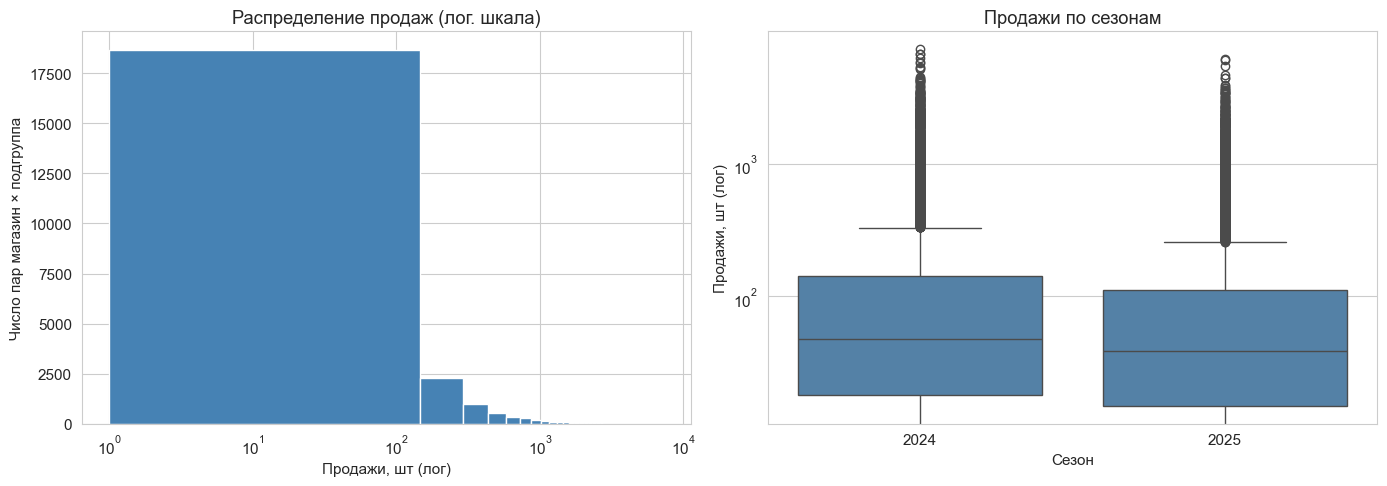

In [34]:
# Подблок 6.3 — Визуализация распределения продаж (гистограмма в логарифмической шкале и boxplot по сезонам — способ показать скошенное распределение, не теряя деталей на хвосте)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df_season.loc[df_season["sales_qty"] > 0, "sales_qty"],
    bins=50, color="steelblue", edgecolor="white"
)
axes[0].set_xscale("log")
axes[0].set_title("Распределение продаж (лог. шкала)")
axes[0].set_xlabel("Продажи, шт (лог)")
axes[0].set_ylabel("Число пар магазин × подгруппа")

sns.boxplot(data=df_season, x="season", y="sales_qty", ax=axes[1], color="steelblue")
axes[1].set_yscale("log")
axes[1].set_title("Продажи по сезонам")
axes[1].set_xlabel("Сезон")
axes[1].set_ylabel("Продажи, шт (лог)")

plt.tight_layout()
save_fig(fig, "01_sales_distribution")
plt.show()

Сохранено: 02_weekly_dynamics.png


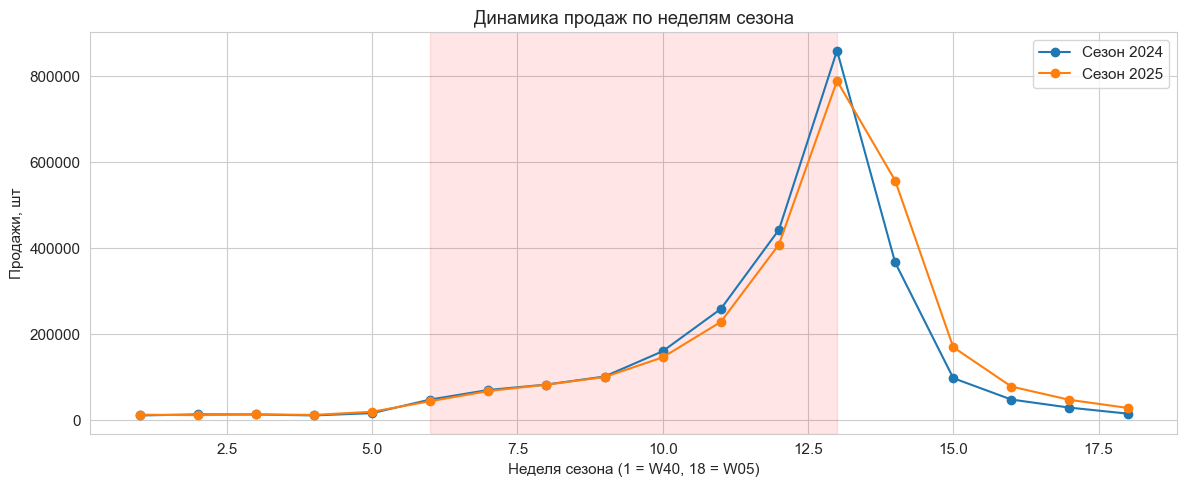

Сезон 2024: пик на неделе 52 (позиция 13 из 18), продажи 860,257 шт
Сезон 2025: пик на неделе 52 (позиция 13 из 18), продажи 789,716 шт


In [35]:
# Подблок 6.4 — Динамика продаж по неделям и определение пика сезона (недели идут не по числовому порядку номера (40, 41, ..., 52, 1, 2, ...), а по хронологии внутри сезона, строится порядковый номер недели сезона (1–18), чтобы график не разрывался на границе календарного года)
# хронологический порядок недель внутри сезона: 40..52, затем 1..05
week_order = list(range(40, 53)) + list(range(1, 6))
week_position = {w: i + 1 for i, w in enumerate(week_order)}

weekly_totals = (
    df_week.groupby(["season", "iso_week"], as_index=False)["sales_qty"].sum()
)
weekly_totals["week_position"] = weekly_totals["iso_week"].map(week_position)
weekly_totals = weekly_totals.sort_values(["season", "week_position"])

fig, ax = plt.subplots(figsize=(12, 5))
for season, group in weekly_totals.groupby("season"):
    ax.plot(group["week_position"], group["sales_qty"], marker="o", label=f"Сезон {season}")

ax.set_xlabel("Неделя сезона (1 = W40, 18 = W05)")
ax.set_ylabel("Продажи, шт")
ax.set_title("Динамика продаж по неделям сезона")
ax.legend()
ax.axvspan(6, 13, alpha=0.1, color="red", label="ноябрь–декабрь")  # примерная зона основного сезона

plt.tight_layout()
save_fig(fig, "02_weekly_dynamics")
plt.show()

# определяем пик — неделю с максимальными продажами по каждому сезону
for season, group in weekly_totals.groupby("season"):
    peak_row = group.loc[group["sales_qty"].idxmax()]
    print(f"Сезон {season}: пик на неделе {int(peak_row['iso_week']):02d} "
          f"(позиция {int(peak_row['week_position'])} из 18), "
          f"продажи {peak_row['sales_qty']:,.0f} шт")

**Выводы 6.4:**

Пик новогоднего спроса пришёлся на неделю **52** (последняя календарная неделя перед 31 декабря) — и это совпало **в обоих сезонах**, 2024 и 2025. Такая устойчивость подтверждает, что пиковая неделя определяется структурой спроса, а не случайными колебаниями конкретного года.

Продажи в пиковую неделю: 860 257 шт. (сезон 2024) против 789 716 шт. (сезон 2025) — снижение на 8.2%, что согласуется с общим замедлением, которое мы уже видели в октябрьском коэффициенте роста (0.945).

Форма кривой одинакова для обоих сезонов: продажи плавно нарастают с недели 45 (начало ноября), резко ускоряются в последние 3–4 недели перед Новым годом и обрываются сразу после 31 декабря — уже к неделе 02 объём падает практически до базового уровня. Это классический паттерн «предновогоднего ажиотажа»: основная масса покупок концентрируется не равномерно по двум месяцам, а именно в финальном рывке.

Граница основного сезона, выбранная в Блоке 5 (недели 45–52, период `season`), подтверждается данными: она захватывает и фазу нарастания, и сам пик, не обрезая существенную часть спроса. Октябрь (`period = october`) обоснованно остаётся вне целевого окна — на графике видно, что продажи там пренебрежимо малы относительно пика.

Сохранено: 03_top_subgroups_by_season.png


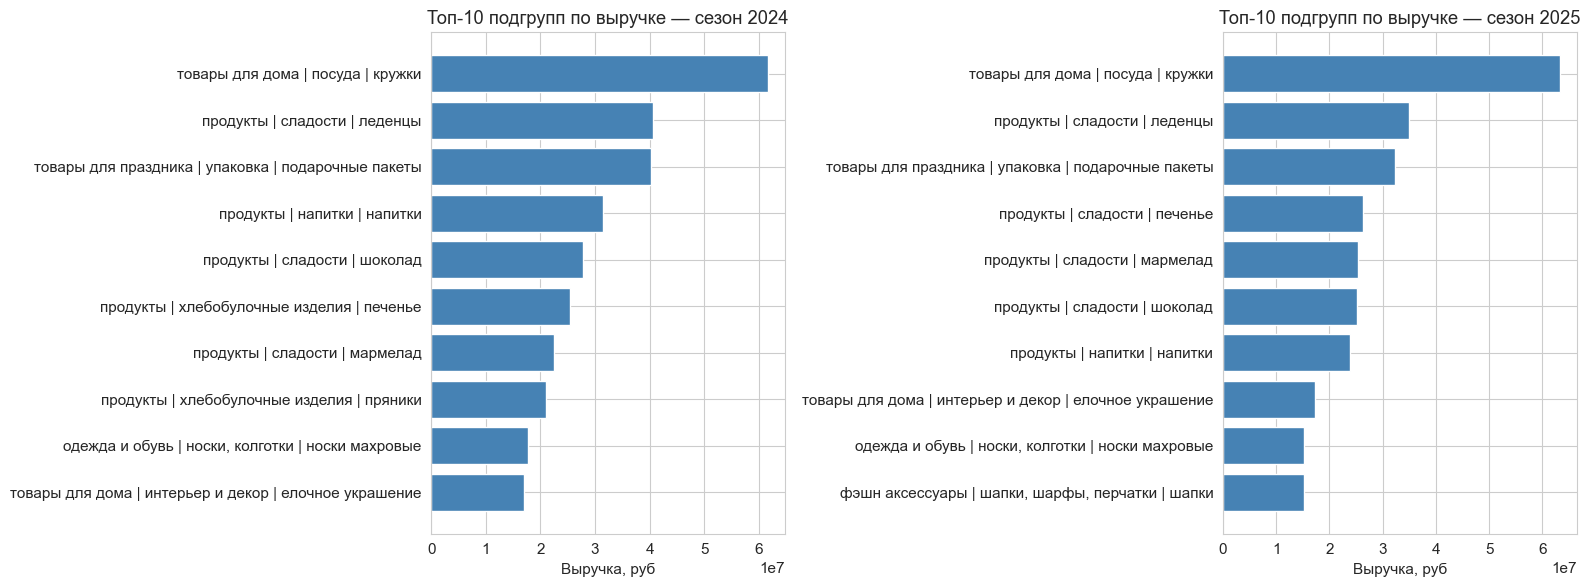

In [36]:
# Подблок 6.5 — Сравнение сезонов: топ подгрупп по выручке (приоритизация идёт по рублям, а не по штукам — иначе дешёвая мелочёвка (упаковка, сладости) обгонит дорогие подгруппы просто за счёт количества)
top_subgroups = (
    df_season.groupby(["season", "subgroup_key"], as_index=False)["sales_rub"].sum()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, season in zip(axes, sorted(df_season["season"].unique())):
    top10 = (
        top_subgroups[top_subgroups["season"] == season]
        .nlargest(10, "sales_rub")
        .sort_values("sales_rub")
    )
    ax.barh(top10["subgroup_key"], top10["sales_rub"], color="steelblue")
    ax.set_title(f"Топ-10 подгрупп по выручке — сезон {season}")
    ax.set_xlabel("Выручка, руб")

plt.tight_layout()
save_fig(fig, "03_top_subgroups_by_season")
plt.show()

Сохранено: 04_stockout_by_cluster.png


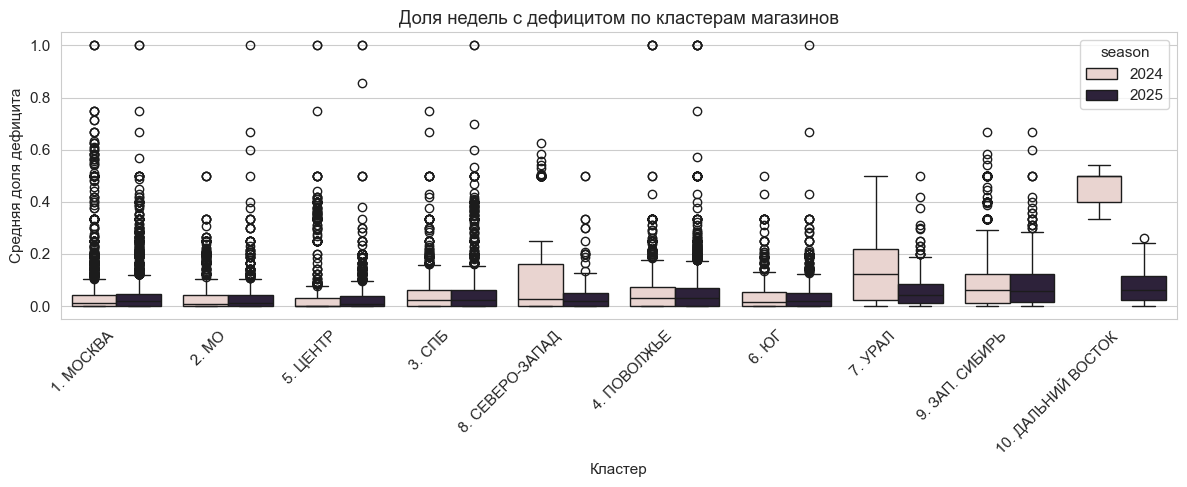

Средний уровень дефицита по кластерам:
cluster
10. ДАЛЬНИЙ ВОСТОК    0.256825
9. ЗАП. СИБИРЬ        0.089564
7. УРАЛ               0.087724
8. СЕВЕРО-ЗАПАД       0.087124
4. ПОВОЛЖЬЕ           0.055492
3. СПБ                0.051733
1. МОСКВА             0.041728
6. ЮГ                 0.038593
5. ЦЕНТР              0.037943
2. МО                 0.035145


In [37]:
# Подблок 6.6 — Распределение дефицита по кластерам (проверка - концентрируется ли дефицит в конкретных кластерах магазинов (прямой input для бизнес-рекомендаций))
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_season, x="cluster", y="avg_stockout_rate", hue="season", ax=ax
)
ax.set_title("Доля недель с дефицитом по кластерам магазинов")
ax.set_xlabel("Кластер")
ax.set_ylabel("Средняя доля дефицита")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig(fig, "04_stockout_by_cluster")
plt.show()

print("Средний уровень дефицита по кластерам:")
print(
    df_season.groupby("cluster")["avg_stockout_rate"]
    .mean()
    .sort_values(ascending=False)
    .to_string()
)

In [38]:
# Подблок 6.7 — ABC-XYZ анализ по товарным подгруппам
# ABC — вклад подгруппы в выручку (накопительно, правило Парето: A — топ-80%, B — следующие 15%, C — оставшиеся 5%)
# XYZ — стабильность спроса по неделям внутри сезона (коэффициент вариации: X < 0.3 стабильно, Y 0.3–0.7 средне, Z > 0.7 нестабильно)
# --- ABC: доля подгруппы в суммарной выручке, накопительно ---
subgroup_revenue = (
    df_season.groupby("subgroup_key", as_index=False)["sales_rub"].sum()
    .sort_values("sales_rub", ascending=False)
)
subgroup_revenue["share"] = subgroup_revenue["sales_rub"] / subgroup_revenue["sales_rub"].sum()
subgroup_revenue["cum_share"] = subgroup_revenue["share"].cumsum()

def abc_class(cum_share):
    if cum_share <= 0.80:
        return "A"
    elif cum_share <= 0.95:
        return "B"
    else:
        return "C"

subgroup_revenue["ABC"] = subgroup_revenue["cum_share"].apply(abc_class)

# --- XYZ: коэффициент вариации понедельных продаж внутри сезона ---
weekly_by_subgroup = (
    df_week[df_week["period"] == "season"]
    .groupby(["subgroup_key", "season", "iso_week"], as_index=False)["sales_qty"].sum()
)
cv = (
    weekly_by_subgroup.groupby("subgroup_key")["sales_qty"]
    .agg(lambda x: x.std() / x.mean() if x.mean() > 0 else float("inf"))
    .reset_index(name="cv")
)

def xyz_class(cv_value):
    if cv_value < 0.3:
        return "X"
    elif cv_value < 0.7:
        return "Y"
    else:
        return "Z"

cv["XYZ"] = cv["cv"].apply(xyz_class)

# объединение
abc_xyz = subgroup_revenue.merge(cv[["subgroup_key", "cv", "XYZ"]], on="subgroup_key")
abc_xyz["ABC_XYZ"] = abc_xyz["ABC"] + abc_xyz["XYZ"]

print("Распределение по группам ABC-XYZ:")
print(abc_xyz["ABC_XYZ"].value_counts().sort_index().to_string())

print("\nЗолотой фонд (AX) — стабильно и много продаётся:")
print(abc_xyz.loc[abc_xyz["ABC_XYZ"] == "AX", "subgroup_key"].to_string(index=False))

Распределение по группам ABC-XYZ:
ABC_XYZ
AX     2
AY     4
AZ    23
BX     1
BY     5
BZ    18
CY     8
CZ    22

Золотой фонд (AX) — стабильно и много продаётся:
  фэшн аксессуары | шапки, шарфы, перчатки | шапки
фэшн аксессуары | шапки, шарфы, перчатки | перч...


Сохранено: 05_abc_xyz_matrix.png


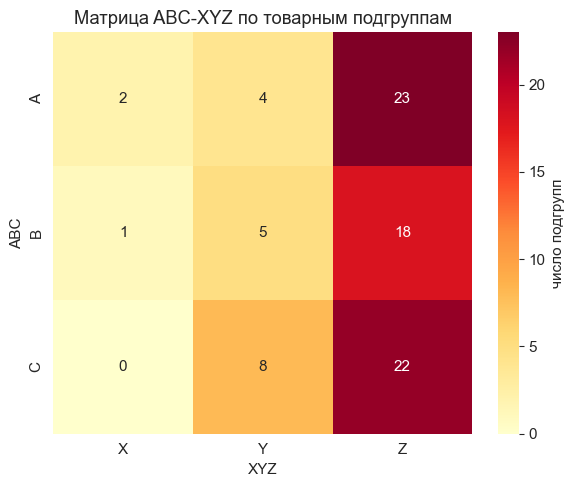

In [39]:
# тепловая карта матрицы ABC-XYZ
matrix = abc_xyz.pivot_table(
    index="ABC", columns="XYZ", values="subgroup_key", aggfunc="count", fill_value=0
).reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="YlOrRd", ax=ax, cbar_kws={"label": "число подгрупп"})
ax.set_title("Матрица ABC-XYZ по товарным подгруппам")
plt.tight_layout()
save_fig(fig, "05_abc_xyz_matrix")
plt.show()

In [40]:
# Подблок 6.8 — Сохранение результатов EDA
abc_xyz.to_parquet(PROCESSED_DIR / "abc_xyz.parquet", index=False)
print(f"Сохранено: {PROCESSED_DIR / 'abc_xyz.parquet'}")
print(f"\nВсего графиков сохранено в {FIGURES_DIR}: {len(list(FIGURES_DIR.glob('*.png')))}")

Сохранено: C:\Users\irma4\Desktop\final_project_hse_eremina\data\processed\abc_xyz.parquet

Всего графиков сохранено в C:\Users\irma4\Desktop\final_project_hse_eremina\output\figures: 6


**Выводы по Блоку 6:**

**Распределение продаж.** Продажи по парам «магазин × подгруппа» сильно скошены вправо (среднее 158.6 шт против медианы 43 шт, отношение 3.69) — небольшое число комбинаций даёт основной объём. Это подтверждает решение анализировать на уровне подгруппы: даже укрупнённая единица сохраняет выраженную неравномерность, на уровне SKU она была бы ещё сильнее.

**Пик сезона.** Определён по данным, а не назначен вручную: неделя 52 (последняя неделя перед 31 декабря) — в обоих сезонах без расхождений. Продажи в пике снизились с 860 257 шт. (2024) до 789 716 шт. (2025), на 8.2%, что согласуется с октябрьским коэффициентом роста (0.945). Граница целевого окна (недели 45–52) подтверждена: она захватывает фазу нарастания и сам пик.

**Топ подгрупп по выручке** — приоритизированы в рублях, а не в штуках, чтобы не завышать вклад дешёвых позиций (упаковка, сладости).

**Дефицит концентрируется географически.** Кластер «Дальний Восток» показывает средний уровень дефицита 25.7% — в 3–7 раз выше остальных кластеров (3.5–9%). Это самая заметная находка блока: вероятная причина — логистическое плечо (дальность доставки от распределительного центра), что требует отдельной проверки в Блоке 7 и может стать основой конкретной бизнес-рекомендации (увеличенный буфер запаса или более ранняя отгрузка для этого кластера).

**ABC-XYZ по подгруппам.** Золотой фонд (AX) — всего 2 подгруппы (шапки, перчатки): стабильный, предсказуемый зимний спрос. Большая часть высокодоходных подгрупп (23 из 29 в категории A) попадает в класс Z (нестабильный спрос) — это ожидаемо для новогоднего ассортимента: резкий скачок продаж в последнюю неделю перед праздником (см. 6.4) закономерно даёт высокий коэффициент вариации, даже если товар в целом продаётся хорошо. Высокая нестабильность здесь — не признак проблемного товара, а сезонная специфика; при интерпретации ошибки прогноза в Блоке 8 закладывать более широкий допуск именно на AZ-группу.

**Ограничение:** матрица ABC-XYZ строится по данным двух сезонов; устойчивость классификации между сезонами отдельно не проверялась и может быть предметом дальнейшего анализа.

## Блок 7: Статистический анализ и проверка гипотез

Описание: формальная проверка закономерностей, обнаруженных в EDA. Каждый тест сопровождается интерпретацией — отдельно статистическая значимость (есть ли эффект) и практическая значимость (важен ли он для бизнеса).

In [41]:
# Подблок 7.1 — Устойчивость ранга подгрупп между сезонами (корреляция Спирмена)
# Вопрос: если подгруппа хорошо продавалась в 2024 году, продаётся ли она так же хорошо в 2025-м? Если да — прошлогодний факт является надёжным признаком для прогноза. Если ранги «перемешиваются» между сезонами — наивный бейзлайн будет работать плохо.
# Спирмен, а не Пирсон — потому что нас интересует сохранение порядка (кто лидер, кто аутсайдер), а не линейная зависимость точных значений.
from scipy import stats

# суммарная выручка подгруппы по каждому сезону
revenue_by_season = (
    df_season.groupby(["subgroup_key", "season"], as_index=False)["sales_rub"].sum()
)

# развернуть в две колонки: сезон 2024 и сезон 2025
revenue_wide = revenue_by_season.pivot(
    index="subgroup_key", columns="season", values="sales_rub"
).dropna()  # остаются только подгруппы, присутствующие в обоих сезонах

rho, p_value = stats.spearmanr(revenue_wide[2024], revenue_wide[2025])

print(f"Подгрупп в сравнении: {len(revenue_wide)}")
print(f"Коэффициент Спирмена: {rho:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    strength = "сильная" if rho > 0.7 else "умеренная" if rho > 0.4 else "слабая"
    print(f"-> Связь статистически значима, сила связи: {strength}")
else:
    print("-> Связь статистически не значима")

Подгрупп в сравнении: 80
Коэффициент Спирмена: 0.906
p-value: 0.0000
-> Связь статистически значима, сила связи: сильная


In [42]:
# Подблок 7.2 — Различие дефицита: Дальний Восток против остальных кластеров
# Гипотеза из EDA: дефицит на Дальнем Востоке (25.7%) заметно выше, чем в остальных кластерах (3.5–9%) (формальная проверка)
# H₀: средний уровень дефицита на Дальнем Востоке не отличается от остальных кластеров.
# H₁: уровень дефицита на Дальнем Востоке выше.
# тест Манна-Уитни, а не классический t-тест: доля дефицита — величина, ограниченная от 0 до 1, с сильным перекосом к нулю (у большинства пар дефицита почти нет), это нарушает предположение t-теста о нормальном распределении; ранговый тест устойчив к такой форме распределения.
far_east = df_season.loc[df_season["cluster"] == "10. ДАЛЬНИЙ ВОСТОК", "avg_stockout_rate"]
other_clusters = df_season.loc[df_season["cluster"] != "10. ДАЛЬНИЙ ВОСТОК", "avg_stockout_rate"]
print(f"Наблюдений: Дальний Восток = {len(far_east)}, остальные = {len(other_clusters)}")
print(f"Средний дефицит: Дальний Восток = {far_east.mean():.3f}, остальные = {other_clusters.mean():.3f}")

u_stat, p_value = stats.mannwhitneyu(far_east, other_clusters, alternative="greater")
print(f"\nU-статистика: {u_stat:.1f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("-> Различие статистически значимо: дефицит на Дальнем Востоке выше")
else:
    print("-> Различие статистически не значимо")

Наблюдений: Дальний Восток = 152, остальные = 24418
Средний дефицит: Дальний Восток = 0.257, остальные = 0.049

U-статистика: 3084234.0
p-value: 0.00000
-> Различие статистически значимо: дефицит на Дальнем Востоке выше


In [43]:
# Подблок 7.3 — Связь дефицита с категорией магазина (χ²-тест)
# Вопрос: зависит ли частота дефицита от категории магазина (Top+, Top, A, B, C, D, E)? Строю таблицу сопряжённости «категория магазина × наличие дефицита» на уровне понедельных наблюдений и проверяю независимость.
# H₀: частота дефицита не зависит от категории магазина.
# H₁: частота дефицита зависит от категории магазина.
# таблица сопряжённости: категория магазина × дефицит (на уровне недели)
contingency = pd.crosstab(df_week["store_category"], df_week["stockout_rate"] > 0)
contingency.columns = ["без дефицита", "с дефицитом"]
print("Таблица сопряжённости:")
print(contingency.to_string())

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nχ² = {chi2:.2f}, степени свободы = {dof}, p-value = {p_value:.5f}")

if p_value < 0.05:
    print("-> Частота дефицита статистически значимо зависит от категории магазина")
else:
    print("-> Значимой зависимости не обнаружено")

Таблица сопряжённости:
                без дефицита  с дефицитом
store_category                           
A                      43281        10654
B                      46152        10117
C                      90445        20167
D                      72941        16031
E                      28182         4481
Top                    28634         5989
Top+                   12548         2729

χ² = 532.87, степени свободы = 6, p-value = 0.00000
-> Частота дефицита статистически значимо зависит от категории магазина


In [44]:
# Подблок 7.4 — Статистическая значимость vs практическая значимость
# Большой объём данных (десятки тысяч наблюдений) делает почти любое различие статистически значимым, даже если оно ничтожно мало в абсолютных цифрах. Поэтому для каждого значимого результата дополнительно оцениваю размер эффекта в понятных единицах — процентных пунктах или рублях.
print("7.3 — категория магазина:")
df_week["_has_stockout"] = df_week["stockout_rate"] > 0

stockout_share_by_cat = (
    df_week.groupby("store_category")["_has_stockout"]
    .mean()
    .sort_values(ascending=False)
)
print(stockout_share_by_cat.to_string())
print(f"  Разброс между лучшей и худшей категорией: "
      f"{(stockout_share_by_cat.max() - stockout_share_by_cat.min()) * 100:.1f} п.п.")

df_week = df_week.drop(columns="_has_stockout")

7.3 — категория магазина:
store_category
A       0.197534
C       0.182322
D       0.180180
B       0.179797
Top+    0.178635
Top     0.172978
E       0.137189
  Разброс между лучшей и худшей категорией: 6.0 п.п.


**Выводы по Блоку 7:**

**7.1. Устойчивость структуры продаж между сезонами.** Ранги товарных подгрупп по выручке демонстрируют очень сильную положительную корреляцию между сезонами 2024 и 2025 (Спирмен ρ = 0.906, p < 0.0001, n = 80 подгрупп, присутствующих в обоих сезонах). Практический вывод: структура спроса на новогодний ассортимент устойчива год к году — лидер продаж прошлого сезона с высокой вероятностью останется лидером в следующем. Это методологически обосновывает наивный LFL-бейзлайн, используемый в Блоке 8: прогноз «от факта прошлого года» опирается на реально устойчивую закономерность, а не на случайное совпадение.

**7.2. Дефицит на Дальнем Востоке — статистически и практически значим.** Уровень дефицита в кластере «Дальний Восток» (25.7%) в 5.2 раза выше, чем в среднем по остальным кластерам (4.9%). Различие подтверждено тестом Манна-Уитни (p < 0.00001) — тест устойчив к скошенности распределения доли дефицита. Это самый практически значимый результат блока: разница такого масштаба указывает на системную, а не случайную проблему, вероятно связанную с логистическим плечом (удалённость от распределительного центра, более редкие поставки). Прямая бизнес-рекомендация: для этого кластера пересмотреть частоту или объём первичной поставки.

**7.3–7.4. Категория магазина — статистически значима, но практически слаба.** Зависимость дефицита от категории магазина статистически подтверждена (χ² = 532.87, p < 0.00001), однако размер эффекта скромный: разброс между категориями составляет всего 6.0 процентных пункта (от 13.7% у категории E до 19.8% у категории A). При выборке из 274 тысяч наблюдений статистическая значимость достигается почти при любом ненулевом различии — сам по себе p-value здесь не говорит о важности эффекта для управленческих решений. В отличие от кластера «Дальний Восток», где и статистический, и практический сигнал совпадают, здесь стоит быть осторожным с выводами: формальная значимость есть, но как основание для конкретных действий (например, менять правила распределения по категориям) эффект недостаточно выражен.

**Общий вывод:** данные показывают одну сильную и однозначную закономерность (устойчивость рангов подгрупп — используется в прогнозе) и одну явную географическую аномалию (Дальний Восток — требует управленческого решения), тогда как связь дефицита с форматом магазина, при формальной значимости, практической ценности почти не несёт.

## Блок 8: Прогноз спроса — бейзлайны и метрики

Описание: два бейзлайна прогноза на сезон 2025 по данным сезона 2024, оценка качества по метрикам WAPE и bias, сравнение подходов в разрезе кластеров и ABC-XYZ групп. Точка отсечки признаков — 15 октября: оба бейзлайна используют только информацию, доступную до начала продаж, это гарантирует отсутствие утечки данных.

In [45]:
# Подблок 8.1 — Разбиение на train (2024) и test (2025)
# Разделение временно́е, а не случайное: всё, что было в 2024 — обучение правил, всё, что в 2025 — проверка. Случайное разбиение здесь некорректно, потому что данные имеют временну́ю структуру.
# Сопоставимые магазины — те, что присутствуют в обоих сезонах. Новые магазины (есть только в 2025) не участвуют в наивном бейзлайне, но остаются в fair share.
train = df_season[df_season["season"] == 2024].copy()
test = df_season[df_season["season"] == 2025].copy()

# сопоставимые магазины — есть в обоих сезонах
stores_train = set(train["store"].unique())
stores_test = set(test["store"].unique())
comparable_stores = stores_train & stores_test
new_stores = stores_test - stores_train

# сопоставимые подгруппы — есть в обоих сезонах
subgroups_train = set(train["subgroup_key"].unique())
subgroups_test = set(test["subgroup_key"].unique())
comparable_subgroups = subgroups_train & subgroups_test
new_subgroups = subgroups_test - subgroups_train

print(f"Train (сезон 2024): {len(train):,} строк, "
      f"{len(stores_train)} магазинов, {len(subgroups_train)} подгрупп")
print(f"Test  (сезон 2025): {len(test):,} строк, "
      f"{len(stores_test)} магазинов, {len(subgroups_test)} подгрупп")
print(f"\nСопоставимых магазинов: {len(comparable_stores)}")
print(f"Новых магазинов (только в 2025): {len(new_stores)}")
print(f"Сопоставимых подгрупп: {len(comparable_subgroups)}")
print(f"Новых подгрупп (только в 2025): {len(new_subgroups)}")
if new_subgroups:
    print(f"  -> {new_subgroups}")

Train (сезон 2024): 10,869 строк, 142 магазинов, 80 подгрупп
Test  (сезон 2025): 13,701 строк, 172 магазинов, 83 подгрупп

Сопоставимых магазинов: 142
Новых магазинов (только в 2025): 30
Сопоставимых подгрупп: 80
Новых подгрупп (только в 2025): 3
  -> {'уходовая косметика | уход за лицом | маски', 'одежда и обувь | тапочки | наборы', 'продукты | сладости | пряности'}


In [46]:
# Подблок 8.2 — Бейзлайн 1: LFL-прогноз
# Логика: продажи подгруппы в магазине за сезон 2025 ≈ факт этого же магазина по этой же подгруппе за 2024 × коэффициент роста сети (0.945, рассчитан в Блоке 5 по октябрю).
# Работает только для сопоставимых пар «магазин × подгруппа», присутствующих в обоих сезонах. Для новых магазинов и новых подгрупп наивный бейзлайн не применим — у них нет факта за прошлый год.
# коэффициент роста, рассчитанный в Блоке 5
print(f"Коэффициент роста (октябрь): {growth_coeff:.3f}")

# факт 2024 по сопоставимым парам
train_comparable = train[
    train["store"].isin(comparable_stores)
    & train["subgroup_key"].isin(comparable_subgroups)
][["store", "subgroup_key", "sales_qty"]].rename(
    columns={"sales_qty": "sales_2024"}
)

# прогноз = факт 2024 × коэффициент роста
train_comparable["forecast_naive"] = train_comparable["sales_2024"] * growth_coeff

# присоединение факта 2025
test_with_naive = test.merge(
    train_comparable[["store", "subgroup_key", "forecast_naive"]],
    on=["store", "subgroup_key"],
    how="inner"  # только пары, для которых есть прогноз
)

print(f"Пар с наивным прогнозом: {len(test_with_naive):,}")
print(f"Пар без прогноза (новые магазины/подгруппы): "
      f"{len(test) - len(test_with_naive):,}")

Коэффициент роста (октябрь): 0.945
Пар с наивным прогнозом: 10,720
Пар без прогноза (новые магазины/подгруппы): 2,981


In [47]:
# Подблок 8.3 — Бейзлайн 2: fair share
# Логика: прогноз для магазина = его доля в общих продажах сети (по данным 2024) × суммарный прогноз по подгруппе на 2025.
# Суммарный прогноз по подгруппе = факт по сети за 2024 × коэффициент роста. Доля магазина считается по сопоставимым магазинам. Преимущество fair share: он может работать и для новых подгрупп (если есть общая доля магазина), но в базовом варианте ограничение теми же сопоставимыми парами, чтобы сравнение с наивным бейзлайном было корректным (одна и та же выборка).
# суммарные продажи подгруппы по сети в 2024
subgroup_total_2024 = (
    train[train["store"].isin(comparable_stores)]
    .groupby("subgroup_key", as_index=False)["sales_qty"]
    .sum()
    .rename(columns={"sales_qty": "subgroup_total_2024"})
)

# доля каждого магазина в продажах подгруппы (по данным 2024)
store_share = train[train["store"].isin(comparable_stores)].merge(
    subgroup_total_2024, on="subgroup_key"
)
store_share["share"] = (
    store_share["sales_qty"] / store_share["subgroup_total_2024"]
)
# обработка деления на ноль: если подгруппа в 2024 не продавалась совсем
store_share["share"] = store_share["share"].fillna(0)

# прогноз fair share = доля магазина × суммарный прогноз по подгруппе
store_share["subgroup_forecast_2025"] = (
    store_share["subgroup_total_2024"] * growth_coeff
)
store_share["forecast_fair"] = (
    store_share["share"] * store_share["subgroup_forecast_2025"]
)

# присоединяем к test
test_with_both = test_with_naive.merge(
    store_share[["store", "subgroup_key", "forecast_fair"]],
    on=["store", "subgroup_key"],
    how="inner"
)

print(f"Пар с обоими прогнозами: {len(test_with_both):,}")
test_with_both[["store", "subgroup_key", "sales_qty",
                 "forecast_naive", "forecast_fair"]].head(10)

Пар с обоими прогнозами: 10,720


,store,subgroup_key,sales_qty,forecast_naive,forecast_fair
0,11003 Москва (Атриум),игры и развлечения | антистресс игрушки | сквиши,21.0,99.273270,99.273270
1,11003 Москва (Атриум),игры и развлечения | брелоки | брелоки,391.0,193.819242,193.819242
2,11003 Москва (Атриум),игры и развлечения | головоломки и конструктор...,34.0,41.600228,41.600228
3,11003 Москва (Атриум),игры и развлечения | игры для маленьких | игро...,56.0,77.527697,77.527697
4,11003 Москва (Атриум),игры и развлечения | игры для маленьких | твор...,114.0,34.036550,34.036550
5,11003 Москва (Атриум),игры и развлечения | настольные игры | развлек...,83.0,51.054825,51.054825
6,11003 Москва (Атриум),"одежда и обувь | носки, колготки | наборы",30.0,78.473156,78.473156
7,11003 Москва (Атриум),"одежда и обувь | носки, колготки | носки высокие",552.0,991.787242,991.787242
8,11003 Москва (Атриум),"одежда и обувь | носки, колготки | носки махровые",488.0,612.657896,612.657896
9,11003 Москва (Атриум),"одежда и обувь | носки, колготки | носки со сп...",118.0,29.309251,29.309251


In [48]:
# Подблок 8.4 — Метрики качества: WAPE и bias
# WAPE (Weighted Absolute Percentage Error) — взвешенная абсолютная процентная ошибка. Формула: сумма |факт - прогноз| / сумма |факт|. Выбрана вместо MAPE: при низких или нулевых продажах MAPE уходит в бесконечность, WAPE устойчив.
# Bias — систематическое отклонение прогноза. Формула: сумма (прогноз - факт) / сумма |факт|. Положительный bias = прогноз систематически завышен (перевоз), отрицательный = занижен (недовоз). Для товародвижения направление ошибки важнее её величины: недовоз и перевоз стоят разных денег.
def calc_wape(actual, forecast):
    """Взвешенная абсолютная процентная ошибка."""
    return abs(actual - forecast).sum() / actual.sum() if actual.sum() > 0 else float("inf")

def calc_bias(actual, forecast):
    """Систематическое отклонение: >0 = перевоз, <0 = недовоз."""
    return (forecast - actual).sum() / actual.sum() if actual.sum() > 0 else float("inf")

# общие метрики по всей выборке
actual = test_with_both["sales_qty"]
naive = test_with_both["forecast_naive"]
fair = test_with_both["forecast_fair"]

print("Общие метрики")
print(f"{'Метрика':<10} {'Наивный LFL':>15} {'Fair Share':>15}")
print(f"{'WAPE':<10} {calc_wape(actual, naive):>14.1%} {calc_wape(actual, fair):>14.1%}")
print(f"{'Bias':<10} {calc_bias(actual, naive):>14.1%} {calc_bias(actual, fair):>14.1%}")

Общие метрики
Метрика        Наивный LFL      Fair Share
WAPE                50.0%          50.0%
Bias                16.3%          16.3%


In [49]:
# Подблок 8.5 — Ошибка в разрезе кластеров (где каждый бейзлайн ошибается сильнее, а где точнее — это покажет, не маскирует ли хорошее среднее плохие результаты по отдельным регионам (особенно важно для Дальнего Востока, где дефицит аномально высок))
results_by_cluster = []
for cluster, group in test_with_both.groupby("cluster"):
    a = group["sales_qty"]
    results_by_cluster.append({
        "cluster": cluster,
        "pairs": len(group),
        "wape_naive": calc_wape(a, group["forecast_naive"]),
        "wape_fair": calc_wape(a, group["forecast_fair"]),
        "bias_naive": calc_bias(a, group["forecast_naive"]),
        "bias_fair": calc_bias(a, group["forecast_fair"]),
    })

df_cluster_metrics = pd.DataFrame(results_by_cluster).sort_values("wape_naive")

print("WAPE и bias по кластерам:")
print(df_cluster_metrics.to_string(index=False, float_format="{:.1%}".format))

WAPE и bias по кластерам:
           cluster  pairs  wape_naive  wape_fair  bias_naive  bias_fair
             6. ЮГ    838       47.9%      47.9%       20.1%      20.1%
             2. МО   1270       48.4%      48.4%        2.5%       2.5%
         1. МОСКВА   3183       48.4%      48.4%       15.3%      15.3%
           7. УРАЛ    225       48.4%      48.4%        6.9%       6.9%
          5. ЦЕНТР   1268       48.7%      48.7%        9.9%       9.9%
            3. СПБ   1288       48.8%      48.8%       26.5%      26.5%
       4. ПОВОЛЖЬЕ   1604       54.9%      54.9%       22.5%      22.5%
    9. ЗАП. СИБИРЬ    675       56.1%      56.1%       26.1%      26.1%
   8. СЕВЕРО-ЗАПАД    297       59.2%      59.2%        4.7%       4.7%
10. ДАЛЬНИЙ ВОСТОК     72       88.8%      88.8%      -88.1%     -88.1%


Сохранено: 06_wape_bias_by_cluster.png


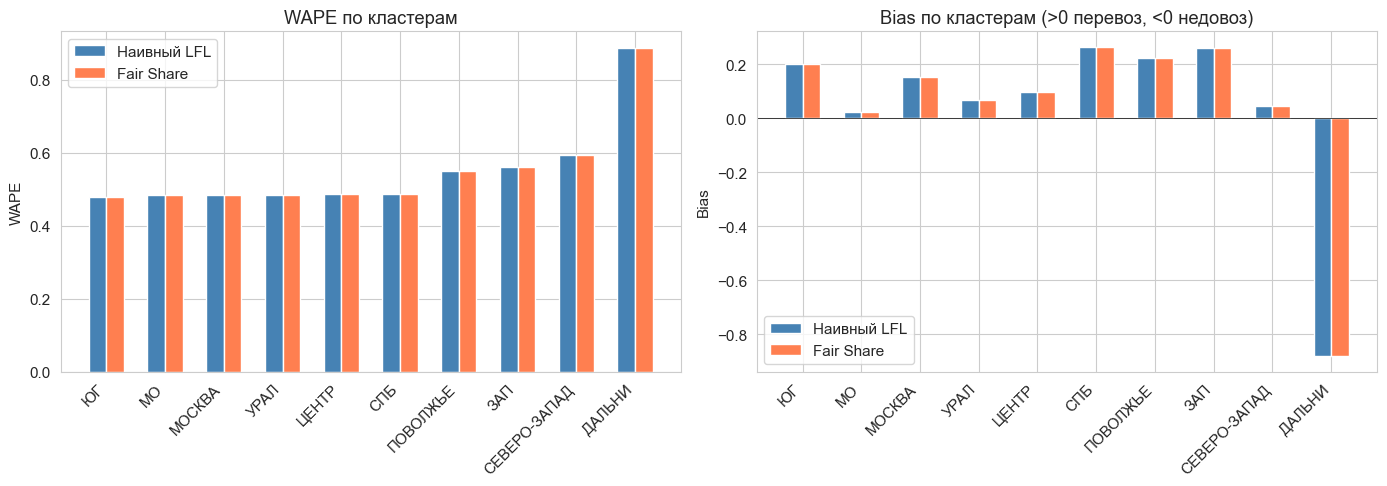

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(df_cluster_metrics))
labels = df_cluster_metrics["cluster"].str.split(". ", expand=True)[1]

axes[0].bar([i - 0.15 for i in x], df_cluster_metrics["wape_naive"],
            width=0.3, label="Наивный LFL", color="steelblue")
axes[0].bar([i + 0.15 for i in x], df_cluster_metrics["wape_fair"],
            width=0.3, label="Fair Share", color="coral")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=45, ha="right")
axes[0].set_ylabel("WAPE")
axes[0].set_title("WAPE по кластерам")
axes[0].legend()

axes[1].bar([i - 0.15 for i in x], df_cluster_metrics["bias_naive"],
            width=0.3, label="Наивный LFL", color="steelblue")
axes[1].bar([i + 0.15 for i in x], df_cluster_metrics["bias_fair"],
            width=0.3, label="Fair Share", color="coral")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_ylabel("Bias")
axes[1].set_title("Bias по кластерам (>0 перевоз, <0 недовоз)")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].legend()

plt.tight_layout()
save_fig(fig, "06_wape_bias_by_cluster")
plt.show()

In [51]:
# Подблок 8.6 — Ошибка в разрезе ABC-XYZ групп
# Ключевой срез: для AX-подгрупп (стабильных и доходных) прогноз должен быть точным — ошибка здесь стоит дороже всего. Для CZ-подгрупп (хаотичных и малозначимых) высокая ошибка ожидаема и терпима.
abc_xyz = pd.read_parquet(PROCESSED_DIR / "abc_xyz.parquet")

test_abc = test_with_both.merge(
    abc_xyz[["subgroup_key", "ABC", "XYZ", "ABC_XYZ"]],
    on="subgroup_key",
    how="left"
)

results_by_abc = []
for group_name, group in test_abc.groupby("ABC_XYZ"):
    a = group["sales_qty"]
    results_by_abc.append({
        "ABC_XYZ": group_name,
        "pairs": len(group),
        "total_sales": a.sum(),
        "wape_naive": calc_wape(a, group["forecast_naive"]),
        "wape_fair": calc_wape(a, group["forecast_fair"]),
    })

df_abc_metrics = (
    pd.DataFrame(results_by_abc)
    .sort_values("ABC_XYZ")
)

print("WAPE по ABC-XYZ группам:")
print(df_abc_metrics.to_string(index=False, float_format="{:.1%}".format))

WAPE по ABC-XYZ группам:
ABC_XYZ  pairs  total_sales  wape_naive  wape_fair
     AX    283   2240800.0%       39.4%      39.4%
     AY    568   4557000.0%       36.7%      36.7%
     AZ   3265 131895200.0%       50.0%      50.0%
     BX    141    290500.0%       46.5%      46.5%
     BY    710   2750200.0%       51.2%      51.2%
     BZ   2530  14534900.0%       46.6%      46.6%
     CY    860   1791900.0%       50.7%      50.7%
     CZ   2363   6461100.0%       69.0%      69.0%


In [52]:
# Подблок 8.7 — Сводная таблица сравнения подходов
print("ИТОГОВОЕ СРАВНЕНИЕ БЕЙЗЛАЙНОВ")

print(f"{'Метрика':<20} {'Наивный LFL':>15} {'Fair Share':>15}")
print("-" * 50)
print(f"{'WAPE (общий)':<20} {calc_wape(actual, naive):>14.1%} {calc_wape(actual, fair):>14.1%}")
print(f"{'Bias (общий)':<20} {calc_bias(actual, naive):>14.1%} {calc_bias(actual, fair):>14.1%}")

winner = "Наивный LFL" if calc_wape(actual, naive) < calc_wape(actual, fair) else "Fair Share"
diff = abs(calc_wape(actual, naive) - calc_wape(actual, fair))

print(f"\n-> Лучший бейзлайн по WAPE: {winner} (разница {diff:.1%})")
print(f"-> Коэффициент роста, использованный в обоих: {growth_coeff:.3f}")
print(f"-> Пар в сравнении: {len(test_with_both):,} "
      f"(из {len(test):,} в сезоне 2025)")

ИТОГОВОЕ СРАВНЕНИЕ БЕЙЗЛАЙНОВ
Метрика                  Наивный LFL      Fair Share
--------------------------------------------------
WAPE (общий)                  50.0%          50.0%
Bias (общий)                  16.3%          16.3%

-> Лучший бейзлайн по WAPE: Fair Share (разница 0.0%)
-> Коэффициент роста, использованный в обоих: 0.945
-> Пар в сравнении: 10,720 (из 13,701 в сезоне 2025)


## Блок 9: Вывод итоговых результатов

Описание: агрегированный отчёт по ключевым метрикам, таблица рекомендованного распределения товара, бизнес-рекомендации и ограничения исследования.

In [53]:
# Подблок 9.1 — Агрегированный отчёт по ключевым метрикам
print("АГРЕГИРОВАННЫЙ ОТЧЁТ ПО ПРОЕКТУ")
print(f"\n--- Данные ---")
print(f"Магазинов в анализе: {df_season['store'].nunique()}")
print(f"Товарных подгрупп: {df_season['subgroup_key'].nunique()}")
print(f"Сезонов: {sorted(df_season['season'].unique().tolist())}")

print(f"\n--- Точность прогноза (сезон 2025 по правилам 2024) ---")
print(f"WAPE: {calc_wape(actual, naive):.1%}")
print(f"Bias: {calc_bias(actual, naive):.1%} (систематический перепрогноз)")

print(f"\n--- Дефицит ---")
overall_stockout = df_season["avg_stockout_rate"].mean()
print(f"Средняя доля дефицита по сети: {overall_stockout:.1%}")
print(f"Дефицит на Дальнем Востоке: {far_east.mean():.1%} "
      f"(в {far_east.mean() / other_clusters.mean():.1f} раза выше среднего)")

print(f"\n--- Экономическая оценка (в масштабированных рублях) ---")
lost_sales_estimate = (
    df_season.loc[df_season["cluster"] == "10. ДАЛЬНИЙ ВОСТОК", "avg_stockout_rate"]
    * df_season.loc[df_season["cluster"] == "10. ДАЛЬНИЙ ВОСТОК", "sales_rub"]
).sum()
print(f"Оценка упущенной выручки из-за дефицита (Дальний Восток, сезон-эквивалент): "
      f"{lost_sales_estimate:,.0f} руб.")

АГРЕГИРОВАННЫЙ ОТЧЁТ ПО ПРОЕКТУ

--- Данные ---
Магазинов в анализе: 172
Товарных подгрупп: 83
Сезонов: [2024, 2025]

--- Точность прогноза (сезон 2025 по правилам 2024) ---
WAPE: 50.0%
Bias: 16.3% (систематический перепрогноз)

--- Дефицит ---
Средняя доля дефицита по сети: 5.0%
Дефицит на Дальнем Востоке: 25.7% (в 5.2 раза выше среднего)

--- Экономическая оценка (в масштабированных рублях) ---
Оценка упущенной выручки из-за дефицита (Дальний Восток, сезон-эквивалент): 306,883 руб.


In [54]:
# Подблок 9.2 — Таблица рекомендованного распределения
# Итоговый артефакт для товародвижения: прогноз на сезон 2025 по каждой паре «магазин × подгруппа», с пометкой уверенности (по ABC-XYZ группе) и признаком аномального кластера
recommendation_table = test_with_both.merge(
    abc_xyz[["subgroup_key", "ABC_XYZ"]], on="subgroup_key", how="left"
)

recommendation_table["confidence"] = recommendation_table["ABC_XYZ"].map({
    "AX": "высокая", "AY": "высокая",
    "BX": "средняя", "BY": "средняя", "AZ": "средняя",
    "CX": "низкая", "CY": "низкая", "BZ": "низкая", "CZ": "низкая",
})

recommendation_table["flag_far_east"] = (
    recommendation_table["cluster"] == "10. ДАЛЬНИЙ ВОСТОК"
)

output_table = recommendation_table[[
    "store", "subgroup_key", "cluster", "store_category",
    "forecast_naive", "sales_qty", "ABC_XYZ", "confidence", "flag_far_east"
]].rename(columns={
    "forecast_naive": "forecast_2025",
    "sales_qty": "actual_2025",
})

print(f"Итоговая таблица: {len(output_table):,} строк")
output_table.head(10)

Итоговая таблица: 10,720 строк


,store,subgroup_key,cluster,store_category,forecast_2025,actual_2025,ABC_XYZ,confidence,flag_far_east
0,11003 Москва (Атриум),игры и развлечения | антистресс игрушки | сквиши,1. МОСКВА,Top,99.273270,21.0,CZ,низкая,False
1,11003 Москва (Атриум),игры и развлечения | брелоки | брелоки,1. МОСКВА,Top,193.819242,391.0,AY,высокая,False
2,11003 Москва (Атриум),игры и развлечения | головоломки и конструктор...,1. МОСКВА,Top,41.600228,34.0,CY,низкая,False
3,11003 Москва (Атриум),игры и развлечения | игры для маленьких | игро...,1. МОСКВА,Top,77.527697,56.0,BZ,низкая,False
4,11003 Москва (Атриум),игры и развлечения | игры для маленьких | твор...,1. МОСКВА,Top,34.036550,114.0,CZ,низкая,False
5,11003 Москва (Атриум),игры и развлечения | настольные игры | развлек...,1. МОСКВА,Top,51.054825,83.0,BZ,низкая,False
6,11003 Москва (Атриум),"одежда и обувь | носки, колготки | наборы",1. МОСКВА,Top,78.473156,30.0,BZ,низкая,False
7,11003 Москва (Атриум),"одежда и обувь | носки, колготки | носки высокие",1. МОСКВА,Top,991.787242,552.0,AZ,средняя,False
8,11003 Москва (Атриум),"одежда и обувь | носки, колготки | носки махровые",1. МОСКВА,Top,612.657896,488.0,AZ,средняя,False
9,11003 Москва (Атриум),"одежда и обувь | носки, колготки | носки со сп...",1. МОСКВА,Top,29.309251,118.0,CZ,низкая,False


In [55]:
# Подблок 9.3 — Сохранение итоговых артефактов
REPORTS_DIR = PROJECT_DIR / "output" / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

output_table.to_csv(REPORTS_DIR / "recommended_distribution.csv", index=False, encoding="utf-8-sig")
df_cluster_metrics.to_csv(REPORTS_DIR / "metrics_by_cluster.csv", index=False, encoding="utf-8-sig")
df_abc_metrics.to_csv(REPORTS_DIR / "metrics_by_abc_xyz.csv", index=False, encoding="utf-8-sig")

print("Сохранены итоговые артефакты:")
for f in REPORTS_DIR.glob("*.csv"):
    print(f"  {f.name}")

Сохранены итоговые артефакты:
  metrics_by_abc_xyz.csv
  metrics_by_cluster.csv
  recommended_distribution.csv


**Подблок 9.4** — Бизнес-рекомендации

Точность базовых правил распределения умеренная (WAPE 50%, систематический перепрогноз +16.3%) — это ожидаемый результат для прогноза на год вперёд по единственному сезону обучения, и он сам по себе является диагностическим инструментом: там, где ошибка выше среднего, есть конкретная и объяснимая причина. Именно эти причины и формируют рекомендации.

**1. Дифференцировать коэффициент роста по кластерам.** Единый сетевой коэффициент (0.945) делает наивный и fair share бейзлайны математически идентичными и усредняет разнонаправленную динамику регионов — от Дальнего Востока с провальным дефицитом до стабильных московских магазинов. Расчёт отдельного коэффициента для каждого кластера — минимальное по трудозатратам изменение с наибольшим потенциальным эффектом на точность; естественный первый шаг для доработки модели.

**2. Пересмотреть логистику для кластера «Дальний Восток».** Здесь сходятся сразу три независимых сигнала: аномально высокий дефицит (25.7%, в 5.2 раза выше сети, подтверждено статистически в Блоке 7), почти двукратный недопрогноз (bias −88.1%) и конкретная оценка упущенной выручки (306 883 руб. в масштабированных цифрах за сезон). Это не шум в данных, а системная проблема снабжения региона, наиболее вероятно связанная с логистическим плечом. Рекомендация: увеличить объём или частоту первичной поставки для этого кластера и скорректировать исторические продажи на дефицит перед использованием в расчёте прогноза следующего сезона.

**3. Применять дифференцированную стратегию по типу подгруппы.** Прогноз для доходных стабильных подгрупп (AX/AY, WAPE 36–39%) заметно надёжнее, чем для малозначимых хаотичных (CZ, WAPE 69%). Практический вывод: модели можно доверять автоматическое распределение по AX/AY, но для CZ-подгрупп ошибка объективно высока и должна компенсироваться экспертной оценкой или увеличенным буфером, а не считаться недоработкой модели.

**4. Учитывать волну спроса при планировании логистики.** Пик продаж устойчиво приходится на последнюю неделю перед 31 декабря в обоих сезонах (Блок 6). Поставки должны быть завершены заранее, а не распределены равномерно по сезону.

**Подблок 9.5** — Ограничения исследования

- **Точность прогноза умеренная (WAPE 50%).** Базовые правила распределения следует использовать как ориентир для первичного распределения, требующий экспертной корректировки, а не как окончательное автоматическое решение. Основной источник ошибки — единственный сезон обучения и единый коэффициент роста для всей сети (см. рекомендацию 1).
- **Дефицит определяется косвенно.** Без справочника планового ассортимента невозможно достоверно отличить «товар не назначен магазину» от «товар распродан и не довезён». Оценка дефицита может быть консервативной (заниженной), а для Дальнего Востока — наоборот, эффект недооценки продаж из-за дефицита мог занизить и точность прогноза, и оценку упущенной выручки.
- **Прогноз построен на одном сезоне обучения.** Коэффициент роста и правила распределения опираются на единственную пару лет (2024 → 2025); устойчивость закономерностей на более длинном горизонте не проверялась.
- **Обезличенные данные.** Выручка масштабирована произвольным коэффициентом в целях конфиденциальности; денежные оценки в отчёте (включая 306 883 руб. упущенной выручки) отражают относительные пропорции, а не реальные суммы компании.

## Блок 10: Прогноз спроса — Ridge-регрессия

Описание: линейная регрессия с регуляризацией как альтернатива бейзлайнам. Вместо одного общего коэффициента роста модель подбирает отдельные веса для каждого признака (кластер, категория магазина, подгруппа, дефицит прошлого сезона) — прямое продолжение находки Блока 8 о том, что единый коэффициент делает оба бейзлайна идентичными.

Модель оценивается на отложенных данных (магазины, не участвовавшие в обучении), чтобы избежать переобучения. Бейзлайны на этой же контрольной выборке пересчитаны заново — для честного сравнения.

In [56]:
# Подблок 10.1 — Подготовка данных и разбиение train/test по магазинам (разбивка по магазинам, а не по строкам: если один и тот же магазин попадёт и в обучение, и в проверку (просто с разными подгруппами), модель может «подсмотреть» его специфику через обучающие строки; разбивка по магазинам гарантирует, что проверочные магазины модель не видела вообще)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# добавление к test_with_both признаков, известных ДО начала сезона 2025:
# факт продаж и уровень дефицита за сезон 2024 (тот же принцип точки отсечки,что и в бейзлайнах Блока 8)
model_data = test_with_both.merge(
    train[["store", "subgroup_key", "sales_qty", "avg_stockout_rate"]]
    .rename(columns={"sales_qty": "sales_2024", "avg_stockout_rate": "stockout_2024"}),
    on=["store", "subgroup_key"],
    how="left"
)
model_data["stockout_2024"] = model_data["stockout_2024"].fillna(0)

print(f"Данные для модели: {len(model_data):,} строк")

# разбивка по магазинам: 75% магазинов — обучение, 25% — проверка
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, holdout_idx = next(splitter.split(model_data, groups=model_data["store"]))

print(f"Обучение: {len(train_idx):,} строк, "
      f"{model_data.iloc[train_idx]['store'].nunique()} магазинов")
print(f"Проверка: {len(holdout_idx):,} строк, "
      f"{model_data.iloc[holdout_idx]['store'].nunique()} магазинов")

# проверка, что магазины не пересекаются между выборками
stores_in_train = set(model_data.iloc[train_idx]["store"])
stores_in_holdout = set(model_data.iloc[holdout_idx]["store"])
print(f"Пересечение магазинов между выборками: {len(stores_in_train & stores_in_holdout)} (должно быть 0)")

Данные для модели: 10,720 строк
Обучение: 8,031 строк, 106 магазинов
Проверка: 2,689 строк, 36 магазинов
Пересечение магазинов между выборками: 0 (должно быть 0)


In [57]:
# Подблок 10.2 — Подготовка признаков
# Категориальные признаки (кластер, категория магазина, подгруппа) превращаются в dummy-переменные — по одному бинарному столбцу на каждое значение. Числовые признаки (продажи и дефицит 2024 года) масштабируются: Ridge чувствителен к масштабу — без этого признак «продажи» (сотни и тысячи) задавил бы признак «дефицит» (доли от 0 до 1) просто по величине чисел, а не по реальной значимости.
# Масштабирование обучается только на train — иначе информация о проверочных магазинах "просочится" в обучение через среднее и стандартное отклонение.
# категориальные признаки -> dummy-переменные (на всех данных сразу, чтобы в train и test были одинаковые столбцы)
categorical_features = pd.get_dummies(
    model_data[["cluster", "store_category", "subgroup_key"]],
    drop_first=True  # убирать одну категорию на признак, чтобы избежать избыточности
)

numeric_features = model_data[["sales_2024", "stockout_2024"]].copy()

X_train_num = numeric_features.iloc[train_idx]
X_holdout_num = numeric_features.iloc[holdout_idx]

# масштабирование: обучение только на train
scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num), columns=X_train_num.columns, index=X_train_num.index
)
X_holdout_num_scaled = pd.DataFrame(
    scaler.transform(X_holdout_num), columns=X_holdout_num.columns, index=X_holdout_num.index
)

X_train = pd.concat([X_train_num_scaled, categorical_features.iloc[train_idx]], axis=1)
X_holdout = pd.concat([X_holdout_num_scaled, categorical_features.iloc[holdout_idx]], axis=1)

y_train = model_data["sales_qty"].iloc[train_idx]
y_holdout = model_data["sales_qty"].iloc[holdout_idx]

print(f"Признаков в модели: {X_train.shape[1]}")
print(f"  из них числовых (масштабированных): 2")
print(f"  из них категориальных (dummy): {X_train.shape[1] - 2}")

Признаков в модели: 96
  из них числовых (масштабированных): 2
  из них категориальных (dummy): 94


In [59]:
# Подблок 10.3 — Обучение Ridge-регрессии и предсказание
# alpha=1.0 — сила регуляризации, стандартное стартовое значение. Регуляризация не даёт модели чрезмерно подстраиваться под обучающие данные (переобучение) — актуально здесь, потому что признаков (после dummy-кодирования подгруппы) много относительно объёма выборки.
# Прогноз продаж не может быть отрицательным — Ridge технически может выдать отрицательное число, поэтому обрезка снизу нулём
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

forecast_ridge_holdout = ridge_model.predict(X_holdout)
forecast_ridge_holdout = forecast_ridge_holdout.clip(min=0)  # продажи не бывают отрицательными

print(f"Модель обучена на {len(X_train):,} строках, {X_train.shape[1]} признаках")
print(f"Прогноз построен для {len(X_holdout):,} строк (отложенные магазины)")

Модель обучена на 8,031 строках, 96 признаках
Прогноз построен для 2,689 строк (отложенные магазины)


In [60]:
# Подблок 10.4 — Честное сравнение с бейзлайнами на той же контрольной выборке
# Бейзлайны в Блоке 8 оценивались на всех сопоставимых магазинах. Здесь пересчет их WAPE и bias только на отложенных магазинах — на тех же данных, на которых проверялась Ridge. Иначе сравнение было бы некорректным: Ridge проверяется на «незнакомых» данных, а бейзлайны — на всей выборке.
holdout_data = model_data.iloc[holdout_idx]

actual_holdout = holdout_data["sales_qty"]
naive_holdout = holdout_data["forecast_naive"]
fair_holdout = holdout_data["forecast_fair"]

print("Сравнение на отложенной выборке (магазины, не участвовавшие в обучении)")
print(f"{'Метод':<15} {'WAPE':>10} {'Bias':>10}")
print("-" * 37)
print(f"{'Наивный LFL':<15} {calc_wape(actual_holdout, naive_holdout):>9.1%} "
      f"{calc_bias(actual_holdout, naive_holdout):>9.1%}")
print(f"{'Fair Share':<15} {calc_wape(actual_holdout, fair_holdout):>9.1%} "
      f"{calc_bias(actual_holdout, fair_holdout):>9.1%}")
print(f"{'Ridge':<15} {calc_wape(actual_holdout, forecast_ridge_holdout):>9.1%} "
      f"{calc_bias(actual_holdout, forecast_ridge_holdout):>9.1%}")

Сравнение на отложенной выборке (магазины, не участвовавшие в обучении)
Метод                 WAPE       Bias
-------------------------------------
Наивный LFL         51.7%     16.4%
Fair Share          51.7%     16.4%
Ridge               33.5%      6.2%


In [61]:
# Подблок 10.5 — Интерпретация коэффициентов
# Каждый коэффициент показывает, как признак связан с прогнозом при прочих равных. Для масштабированных числовых признаков коэффициент — это изменение прогноза при увеличении признака на одно стандартное отклонение. Для dummy-переменных — сдвиг прогноза относительно базовой категории (которая была убрана как референс).
coefficients = pd.Series(ridge_model.coef_, index=X_train.columns).sort_values()

print("10 признаков с наибольшим отрицательным эффектом")
print(coefficients.head(10).to_string())

print("\n10 признаков с наибольшим положительным эффектом")
print(coefficients.tail(10).to_string())

print(f"\nСвободный член (базовый уровень прогноза): {ridge_model.intercept_:.1f}")

10 признаков с наибольшим отрицательным эффектом
subgroup_key_продукты | хлебобулочные изделия | печенье                                         -460.740798
store_category_E                                                                                 -62.691401
subgroup_key_товары для праздника | упаковка | коробки                                           -46.404757
store_category_D                                                                                 -44.514272
store_category_C                                                                                 -30.884079
subgroup_key_товары для праздника | открытки | открытки                                          -28.980492
subgroup_key_фэшн аксессуары | шапки, шарфы, перчатки | жилеты, манишки                          -27.827102
subgroup_key_товары для праздника | праздничные украшения и декорации | аксессуары для декора    -27.205252
subgroup_key_товары для животных | амуниция | намордники, ошейники                     

In [62]:
# Подблок 10.6 — Ошибка Ridge в разрезе кластеров
# Тот же срез, что был для бейзлайнов в Блоке 8 — проверка - лучше ли Ridge справляется именно с Дальним Востоком
holdout_with_ridge = holdout_data.copy()
holdout_with_ridge["forecast_ridge"] = forecast_ridge_holdout

results_ridge_by_cluster = []
for cluster, group in holdout_with_ridge.groupby("cluster"):
    a = group["sales_qty"]
    results_ridge_by_cluster.append({
        "cluster": cluster,
        "pairs": len(group),
        "wape_naive": calc_wape(a, group["forecast_naive"]),
        "wape_ridge": calc_wape(a, group["forecast_ridge"]),
        "bias_naive": calc_bias(a, group["forecast_naive"]),
        "bias_ridge": calc_bias(a, group["forecast_ridge"]),
    })

df_ridge_cluster = pd.DataFrame(results_ridge_by_cluster).sort_values("wape_naive")
print(df_ridge_cluster.to_string(index=False, float_format="{:.1%}".format))

        cluster  pairs  wape_naive  wape_ridge  bias_naive  bias_ridge
        7. УРАЛ     72       42.5%       40.3%        0.5%       30.1%
       5. ЦЕНТР    303       46.9%       30.7%        3.8%        4.9%
      1. МОСКВА    902       48.5%       32.1%       22.6%        6.2%
          6. ЮГ    227       50.2%       31.2%       21.2%        2.7%
         3. СПБ    230       51.5%       27.6%       27.9%       -3.2%
 9. ЗАП. СИБИРЬ     68       55.9%       40.3%      -54.7%        7.5%
          2. МО    365       57.1%       34.7%       -9.7%       -4.7%
    4. ПОВОЛЖЬЕ    455       59.5%       38.8%       34.9%       19.8%
8. СЕВЕРО-ЗАПАД     67       88.7%       63.2%      -88.5%        0.7%


In [63]:
# Подблок 10.7 — Итоговая сводная таблица трёх подходов
summary = pd.DataFrame({
    "Метод": ["Наивный LFL", "Fair Share", "Ridge-регрессия"],
    "WAPE": [
        calc_wape(actual_holdout, naive_holdout),
        calc_wape(actual_holdout, fair_holdout),
        calc_wape(actual_holdout, forecast_ridge_holdout),
    ],
    "Bias": [
        calc_bias(actual_holdout, naive_holdout),
        calc_bias(actual_holdout, fair_holdout),
        calc_bias(actual_holdout, forecast_ridge_holdout),
    ],
})
summary["WAPE"] = summary["WAPE"].apply(lambda x: f"{x:.1%}")
summary["Bias"] = summary["Bias"].apply(lambda x: f"{x:.1%}")

print(summary.to_string(index=False))

summary.to_csv(REPORTS_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
print(f"\nСохранено: {REPORTS_DIR / 'model_comparison.csv'}")

          Метод  WAPE  Bias
    Наивный LFL 51.7% 16.4%
     Fair Share 51.7% 16.4%
Ridge-регрессия 33.5%  6.2%

Сохранено: C:\Users\irma4\Desktop\final_project_hse_eremina\output\reports\model_comparison.csv
